In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sipm.util.functions as func
import pandas as pd
import glob
import scipy
from scipy.interpolate import interp1d
import csv
import os
from sipm.analysis.SipmCalibration import SipmCalibration
import yaml

In [17]:
plt.style.use('darkside')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams['text.usetex'] = os.environ['HOSTNAME'][:9]=='della-vis'

In [18]:
!pwd


/home/as111/sipm-analysis/jupyter


## Example waveforms

trigger_position: 1585
trigger_position: 1585
trigger_position: 1585
trigger_position: 1585
/scratch/gpfs/GALBIATI/data/sipm//xenon_doping/2023-12-13/2023-12-13_volt_96_light_laser_cond_ar/0/wave0.dat
10 events


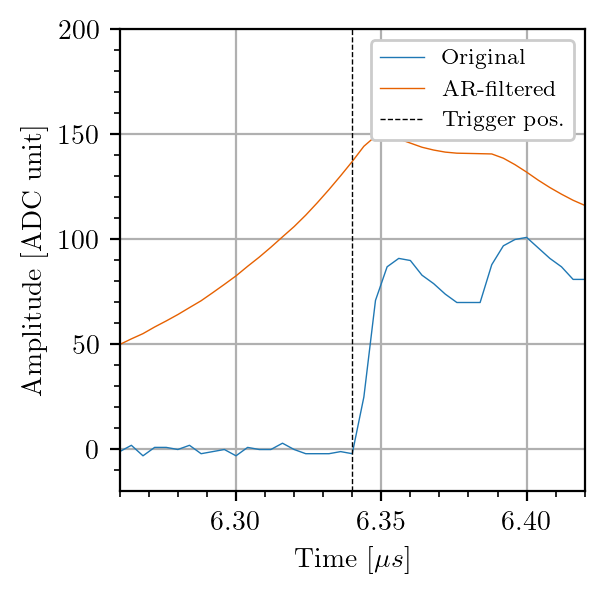

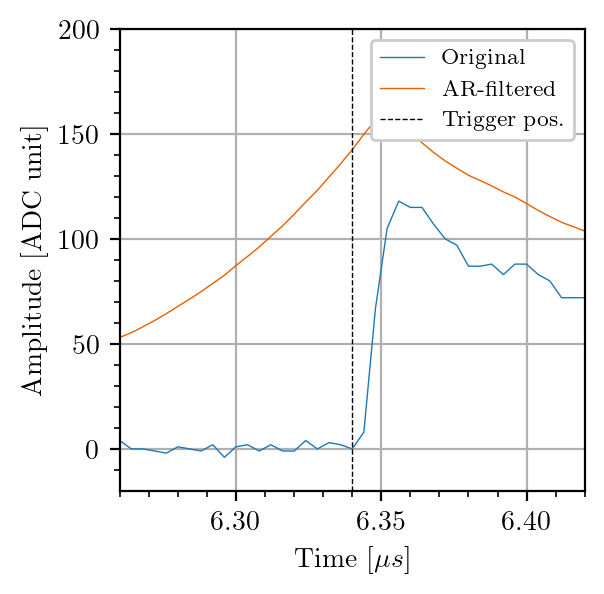

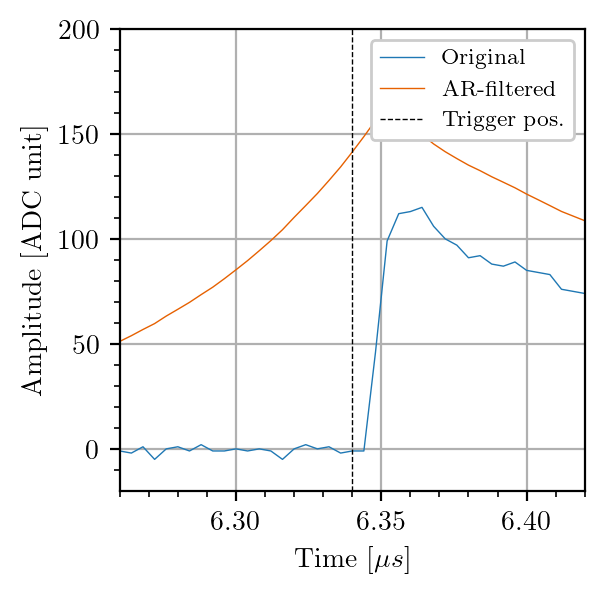

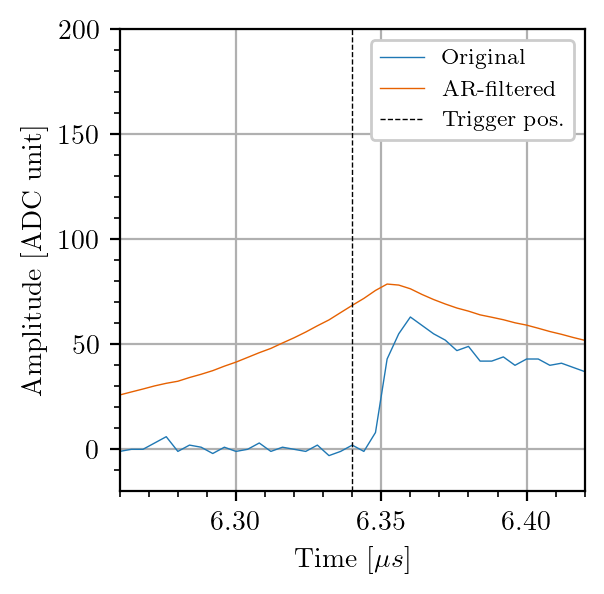

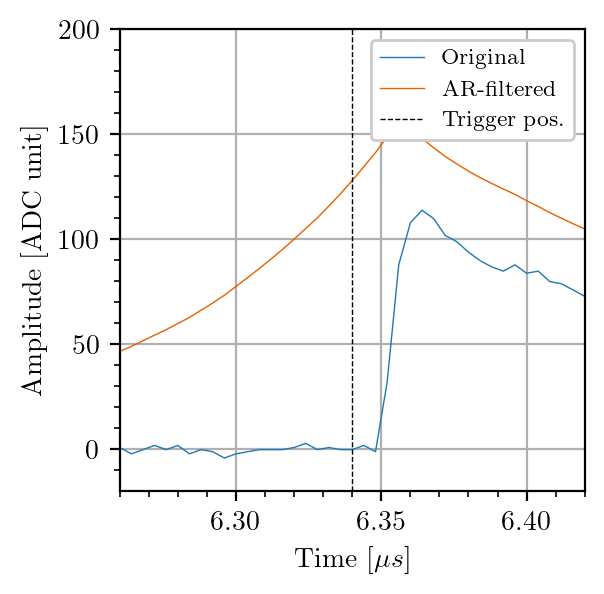

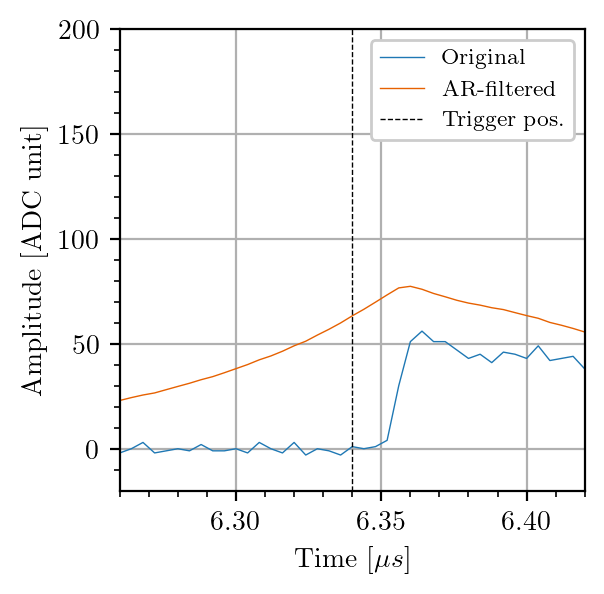

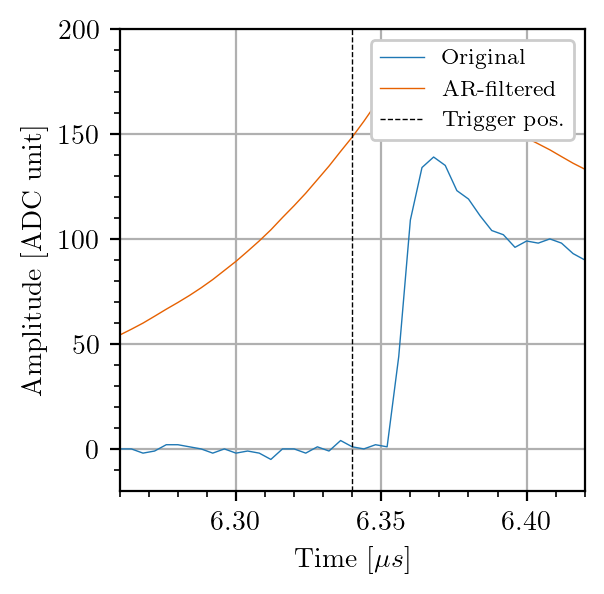

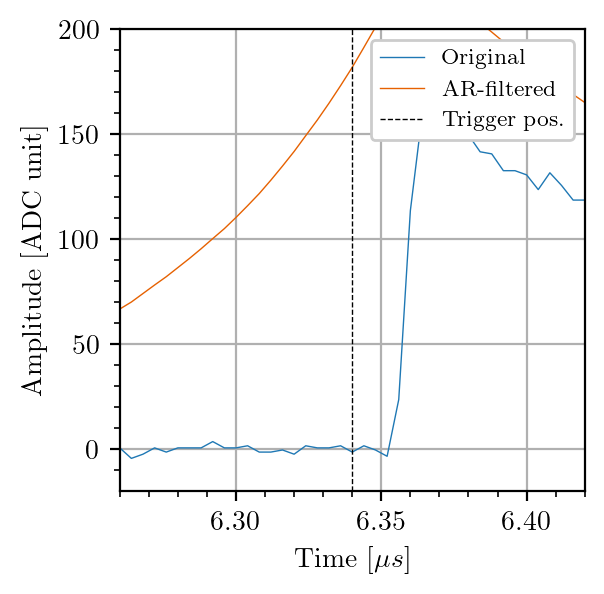

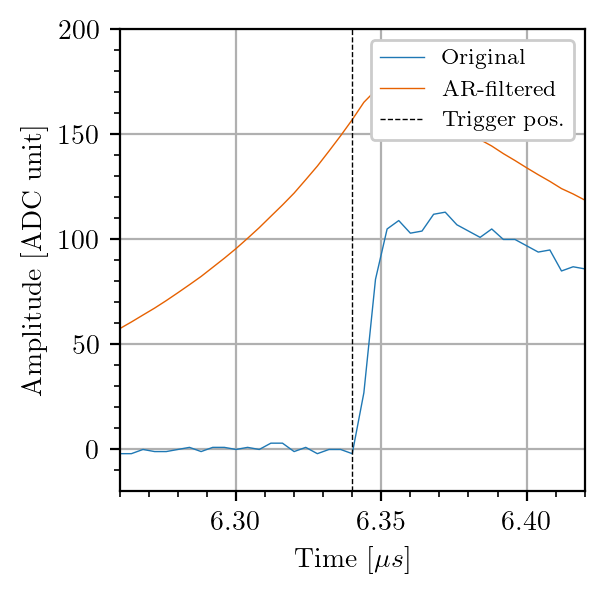

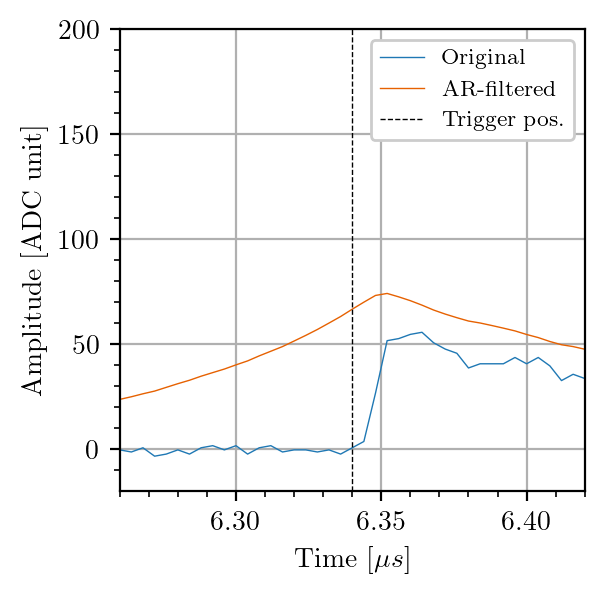

In [19]:
import sipm.recon.WaveformDataset as wfd
data_dir = '/scratch/gpfs/GALBIATI/data/sipm/xenon_doping/'
direc = '2023-12-13/2023-12-13_volt_96_light_laser_cond_ar/0/'
ch = 0
evid = np.arange(0, 10)
trig_pos = 1585
dset = wfd.WaveformDataset(path='{}{}'.format(
    data_dir, direc), pol=-1, channels=range(4), trig = trig_pos)
wfs, arwfs = dset.ch[ch].get_waveforms(ev=evid, ar_filter=True)
ymin, ymax = -20, 200

for i, wf in enumerate(wfs):
    plt.figure(i, figsize=(3, 3))
    plt.plot(dset.ch[ch].time, wf, label='Original', linewidth=0.5)
    plt.plot(dset.ch[ch].time, arwfs[i]*0.1,
             label='AR-filtered', linewidth=0.5)
    plt.plot([trig_pos * dset.ch[ch].sample_step]*2, [ymin, ymax], 'k--', label='Trigger pos.', lw=0.5)
    plt.legend(loc='upper right')
    plt.xlabel(r'Time [$\mu s$]')
    plt.ylabel(r'Amplitude [ADC unit]')
    plt.minorticks_on()
    plt.grid()
    # plt.xlim(0, 16)
    plt.xlim((trig_pos-20)*dset.ch[ch].sample_step, (trig_pos+20)*dset.ch[ch].sample_step)
    plt.ylim(ymin, ymax)

# Load pre-processed h5 files
These files should be processed by `exe/laser_pulse.py` script.

In [20]:
runs = np.arange(10)
channels = np.arange(8)
voltages = [92,94,96,98,100]
directory = '/scratch/gpfs/GALBIATI/as111/results/'
date = '2023-12-13'
verbose = True
metadata_dict = {}
for ch in channels:
    metadata_dict[ch] = {}
    for volt in voltages:
        metadata_dict[ch][volt] = {'metadata':{
                'date': date,
                'volt': volt,
                'light': 'laser',
                'cond': 'ar',
                'ch': ch
            }}
        files = glob.glob(f"{directory}{date}/{date}_volt_{volt}_light_laser_cond_ar_run*_laser_pulse_liq5.h5")
        data = []
        for f in files:
            ind = f.find('run')+3
            run_number = int(f[ind:f.find('_',ind)])
            df = pd.read_hdf(f, key=f'{volt}/{ch}')
            df['event'] = df.index
            df['run'] = np.array([run_number]*df.shape[0])
            data.append(df)
        if len(files)>0:
            data = pd.concat(data, ignore_index=True).sort_values(by=['run','event']).reset_index(drop=True)
        if verbose:
            if len(files)==0:
                events = 0
            else:
                keys = data.keys()
                events = len(data[keys[0]])
            print(f'{date} {volt}V ch{ch} - {len(files)} files {events} events')
        metadata_dict[ch][volt]['data'] = data

2023-12-13 92V ch0 - 10 files 503160 events
2023-12-13 94V ch0 - 10 files 503114 events
2023-12-13 96V ch0 - 10 files 503030 events
2023-12-13 98V ch0 - 10 files 502232 events
2023-12-13 100V ch0 - 10 files 502742 events
2023-12-13 92V ch1 - 10 files 503160 events
2023-12-13 94V ch1 - 10 files 503114 events
2023-12-13 96V ch1 - 10 files 503030 events
2023-12-13 98V ch1 - 10 files 502232 events
2023-12-13 100V ch1 - 10 files 502742 events
2023-12-13 92V ch2 - 10 files 503160 events
2023-12-13 94V ch2 - 10 files 503114 events
2023-12-13 96V ch2 - 10 files 503030 events
2023-12-13 98V ch2 - 10 files 502232 events
2023-12-13 100V ch2 - 10 files 502742 events
2023-12-13 92V ch3 - 10 files 503160 events
2023-12-13 94V ch3 - 10 files 503114 events
2023-12-13 96V ch3 - 10 files 503030 events
2023-12-13 98V ch3 - 10 files 502232 events
2023-12-13 100V ch3 - 10 files 502742 events
2023-12-13 92V ch4 - 10 files 503160 events
2023-12-13 94V ch4 - 10 files 503114 events
2023-12-13 96V ch4 - 10 file

In [21]:
metadata_dict[ch][volt]['data']

,baseline_mean,baseline_rms,amplitude_trig,peakpos_trig,integral_5p00us,event,run
0,3867.932877,1.333299,2180.488998,1588,6064.424658,"(0, 0)",0
1,3867.957534,1.370773,-6.032769,1565,60.493151,"(0, 1)",0
2,3867.697945,1.363365,-4.471991,1565,-96.589041,"(0, 2)",0
3,3868.069863,1.332130,3689.366435,1590,10686.027397,"(0, 3)",0
4,3868.106849,1.301562,2204.696242,1591,8819.630137,"(0, 4)",0
...,...,...,...,...,...,...,...
502737,3867.834247,1.378874,1205.762600,1588,3182.150685,"(9, 50194)",9
502738,3867.576712,1.420112,2137.778386,1589,6011.657534,"(9, 50195)",9
502739,3868.382192,1.425486,371.628263,1590,1179.561644,"(9, 50196)",9
502740,3868.175342,1.438491,950.421181,1588,3201.931507,"(9, 50197)",9


## Baseline quality cut
To avoid pre-trigger pulses or abnormal fluctuations, we require that the RMS variation in the baseline region ($t<t_{\rm trigger}-0.5~\rm\mu s$) be less than $2.5$ ADC units.
This baseline cut normalizes the baseline mean distribution.
Cut fraction is around $0.1\%$ ($2\%$) for the top (bottom) tile.

In [22]:
verbose = True
thre_ch = [2.0]*8
mybsl = {}
for ch in channels:
    mybsl[ch] = {}
    for volt in voltages:
        mybsl[ch][volt] = {'rms_threshold': thre_ch[ch]}
        data = metadata_dict[ch][volt]['data']
        data['bsl_cut'] = data['baseline_rms']<mybsl[ch][volt]['rms_threshold']
        rms_hist, rms_bins = np.histogram(data['baseline_rms'], bins=500, range=(0, 8))
        mean_hist, mean_bins = np.histogram(data['baseline_mean'], bins=1500, range=(3850, 3900))
        mean_hist_cut, mean_bins_cut = np.histogram(data['baseline_mean'].loc[data['bsl_cut']], bins=1500, range=(3850, 3900))
        cut_fraction = 1-np.sum(data['bsl_cut'])/data.shape[0]
        mybsl[ch][volt].update({
            'rms_hist':rms_hist, 'rms_bins':rms_bins,
            'mean_hist':mean_hist, 'mean_bins':mean_bins,
            'mean_hist_cut':mean_hist_cut, 'mean_bins_cut':mean_bins_cut,
            'cut_fraction':cut_fraction
        })
        if verbose:
            print(f'{volt}V ch{ch} cut fraction = {cut_fraction*100:.5f}%')
            

92V ch0 cut fraction = 0.01590%
94V ch0 cut fraction = 0.01729%
96V ch0 cut fraction = 1.51164%
98V ch0 cut fraction = 0.02847%
100V ch0 cut fraction = 0.02367%
92V ch1 cut fraction = 0.01729%
94V ch1 cut fraction = 0.01769%
96V ch1 cut fraction = 0.01968%
98V ch1 cut fraction = 0.02350%
100V ch1 cut fraction = 0.02268%
92V ch2 cut fraction = 0.01292%
94V ch2 cut fraction = 0.01650%
96V ch2 cut fraction = 0.02306%
98V ch2 cut fraction = 0.02250%
100V ch2 cut fraction = 0.01929%
92V ch3 cut fraction = 0.01550%
94V ch3 cut fraction = 0.01729%
96V ch3 cut fraction = 0.01869%
98V ch3 cut fraction = 0.02688%
100V ch3 cut fraction = 0.03720%
92V ch4 cut fraction = 0.01014%
94V ch4 cut fraction = 0.01630%
96V ch4 cut fraction = 0.96137%
98V ch4 cut fraction = 0.02230%
100V ch4 cut fraction = 0.01850%
92V ch5 cut fraction = 0.01431%
94V ch5 cut fraction = 0.01968%
96V ch5 cut fraction = 0.02067%
98V ch5 cut fraction = 0.02847%
100V ch5 cut fraction = 0.01830%
92V ch6 cut fraction = 0.01391%
94

Text(0.07, 0.5, 'Count')

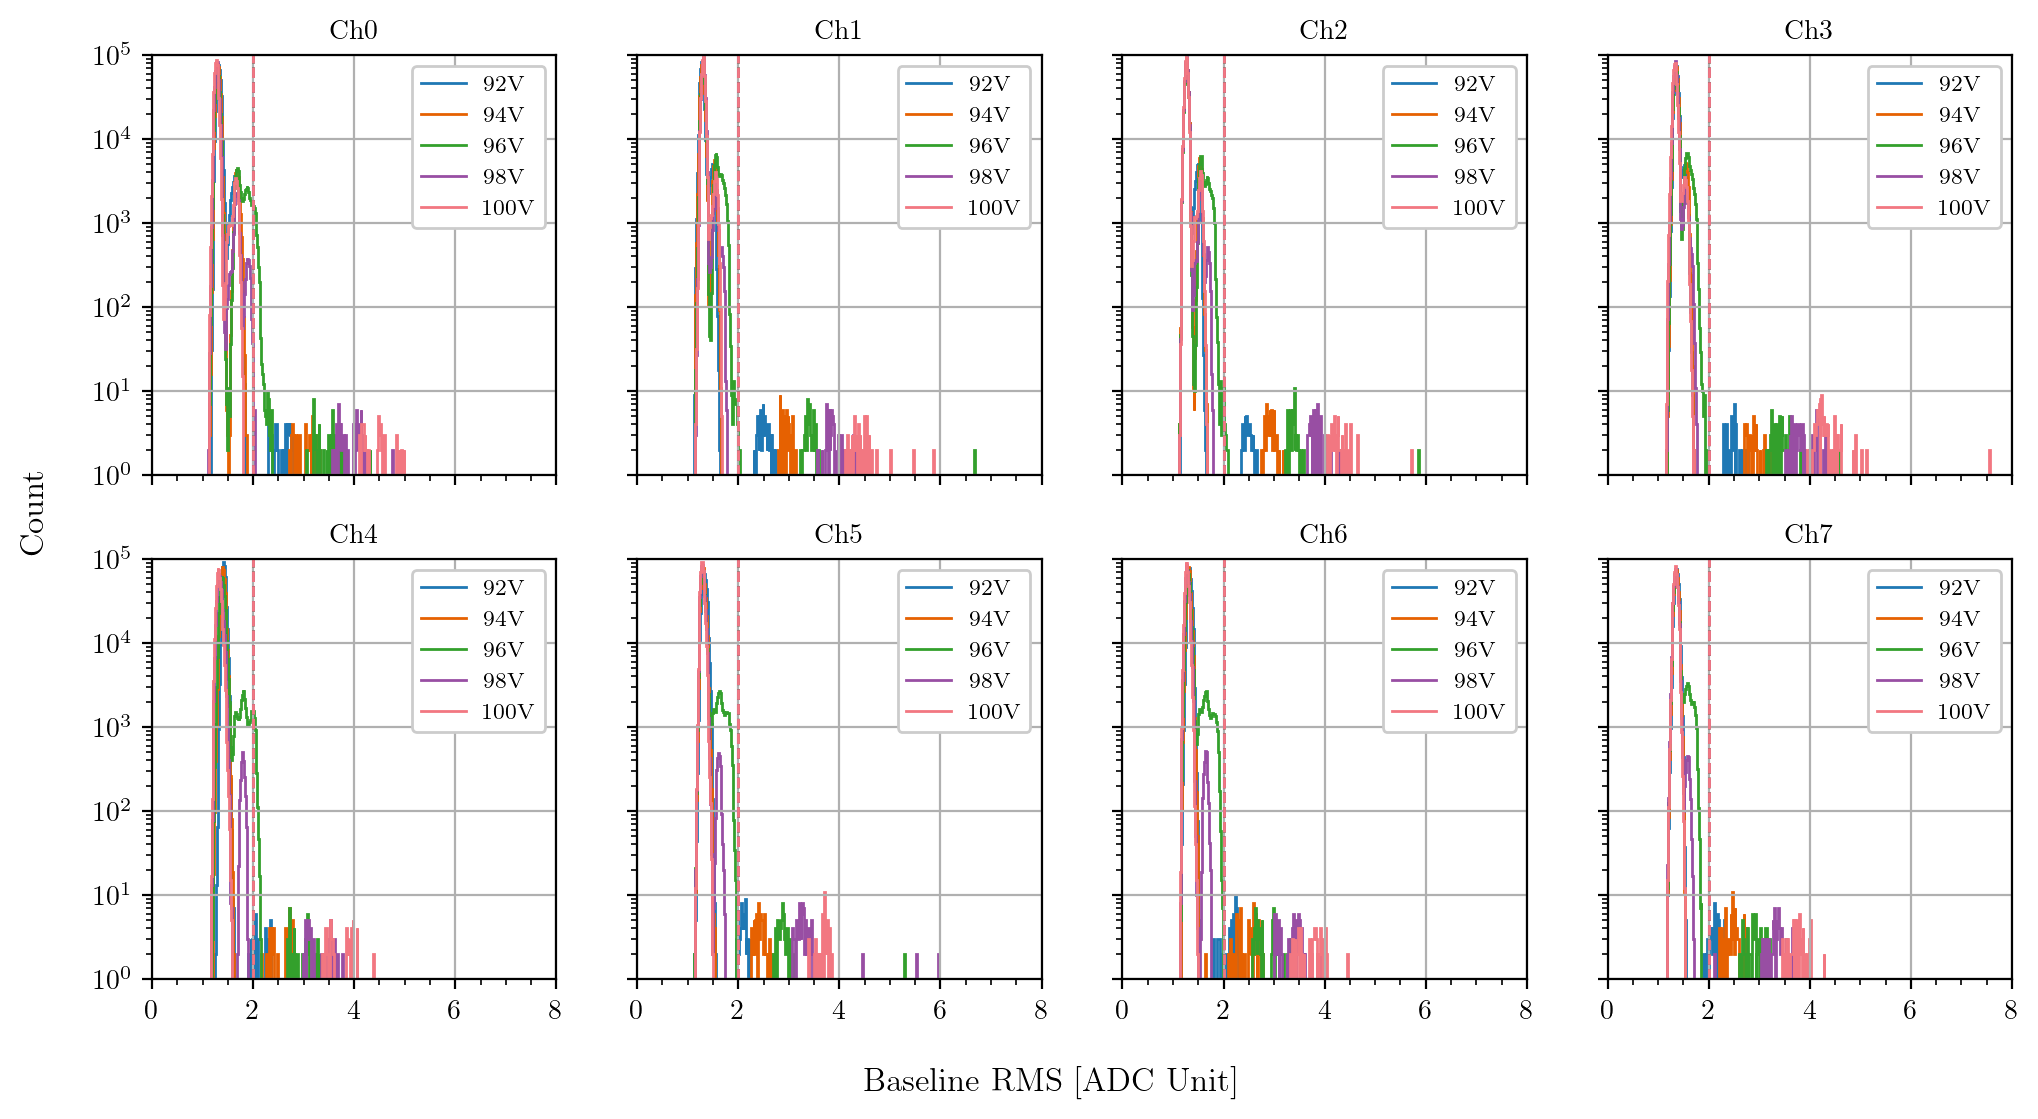

In [23]:
# Make plots for all datasets
# Baseline RMS
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    for k, volt in enumerate(voltages):
        axs[j//4,j%4].stairs(mybsl[ch][volt]['rms_hist'],
                            mybsl[ch][volt]['rms_bins'],
                            label=f'{volt}V', color=f'C{k}')
        th = mybsl[ch][volt]['rms_threshold']
        axs[j//4,j%4].plot([th, th], [1, 1e5], f'C{k}--', linewidth=1)
    axs[j//4,j%4].legend(loc='upper right')
    axs[j//4,j%4].set_ylim(1, 1e5)
    axs[j//4,j%4].set_yscale('log')
    axs[j//4,j%4].minorticks_on()
    axs[j//4,j%4].grid()
    axs[j//4,j%4].set_title(f'Ch{ch}')
fig.supxlabel('Baseline RMS [ADC Unit]', y=0.01)
fig.supylabel('Count', x=0.07)

Text(0.07, 0.5, 'Count')

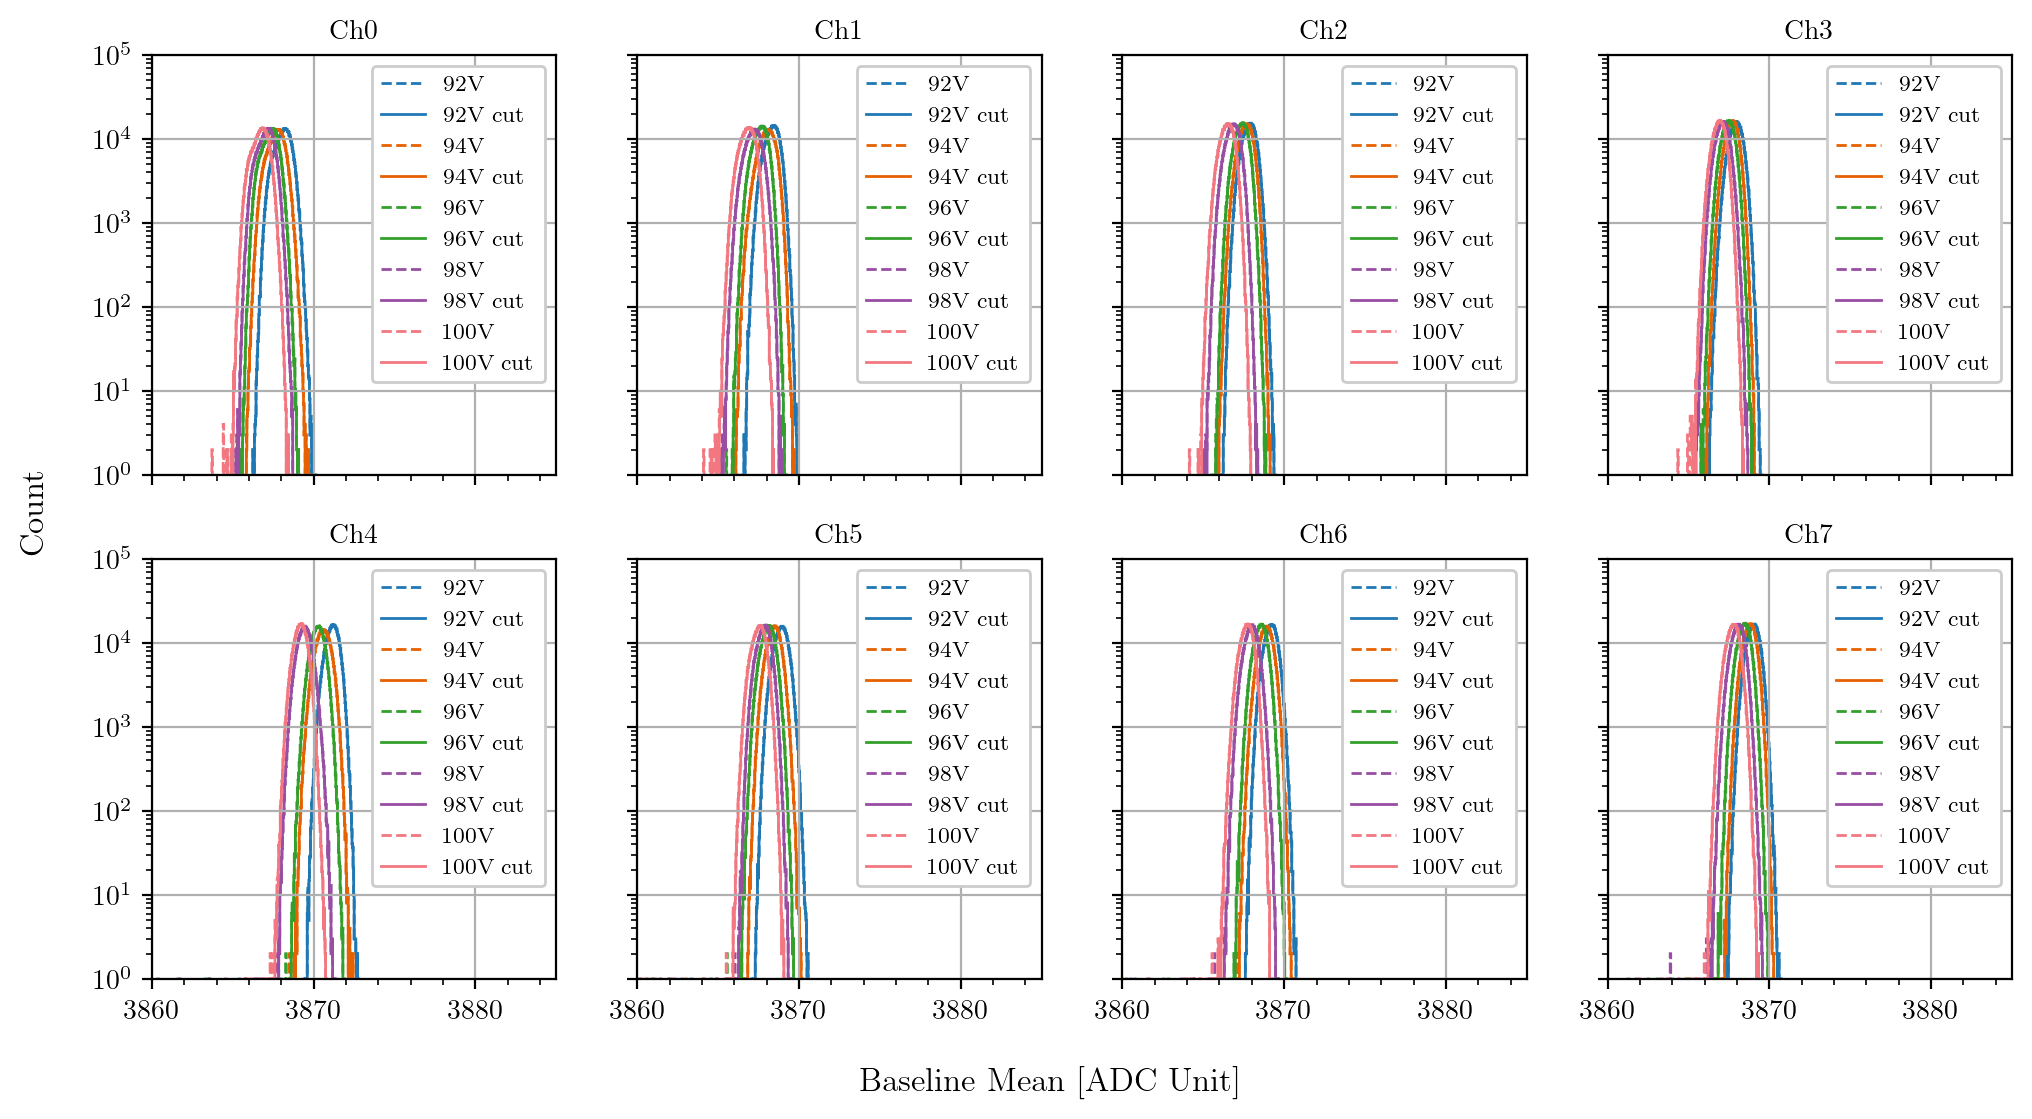

In [24]:
# Make plots for all datasets
# Baseline mean
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    for k, volt in enumerate(voltages):
        axs[j//4,j%4].stairs(mybsl[ch][volt]['mean_hist'],
                mybsl[ch][volt]['mean_bins'],
                label=f'{volt}V', color=f'C{k}', linestyle='--')
        axs[j//4,j%4].stairs(mybsl[ch][volt]['mean_hist_cut'],
                            mybsl[ch][volt]['mean_bins_cut'],
                            label=f'{volt}V cut', color=f'C{k}')
    axs[j//4,j%4].legend(loc='upper right')
    axs[j//4,j%4].set_ylim(1, 1e5)
    axs[j//4,j%4].set_yscale('log')
    axs[j//4,j%4].minorticks_on()
    axs[j//4,j%4].grid()
    axs[j//4,j%4].set_title(f'Ch{ch}')
    axs[j//4,j%4].set_xlim(3860,3885)
fig.supxlabel('Baseline Mean [ADC Unit]', y=0.01)
fig.supylabel('Count', x=0.07)

Plots for ch0 92V


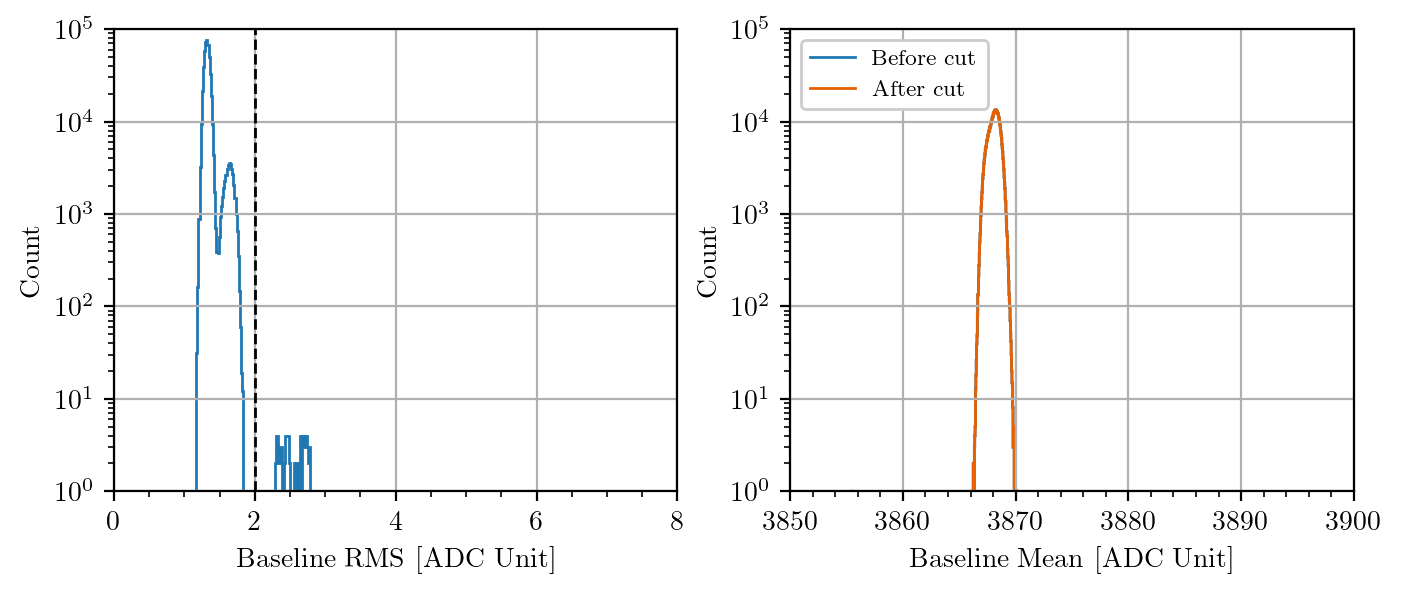

In [25]:
# Make plots for selected dataset
ch = 0
volt = 92
print(f'Plots for ch{ch} {volt}V')
fig, axs = plt.subplots(1, 2)
fig.set_size_inches(8, 3)

# rms
axs[0].stairs(mybsl[ch][volt]['rms_hist'],
              mybsl[ch][volt]['rms_bins'])
th = mybsl[ch][volt]['rms_threshold']
axs[0].plot([th, th], [1, 1e5], 'k--', linewidth=1)
axs[0].set_ylim(1, 1e5)
axs[0].set_yscale('log')
axs[0].set_xlabel('Baseline RMS [ADC Unit]')
axs[0].set_ylabel('Count')
axs[0].minorticks_on()
axs[0].grid()

# mean
axs[1].stairs(mybsl[ch][volt]['mean_hist'],
              mybsl[ch][volt]['mean_bins'],
              label='Before cut')
axs[1].stairs(mybsl[ch][volt]['mean_hist_cut'],
              mybsl[ch][volt]['mean_bins_cut'],
              label='After cut')
axs[1].legend()
axs[1].set_yscale('log')
axs[1].set_ylim(1, 1e5)
axs[1].set_xlim(mybsl[ch][volt]['mean_bins'][0], mybsl[ch][volt]['mean_bins'][-1])
axs[1].set_xlabel('Baseline Mean [ADC Unit]')
axs[1].set_ylabel('Count')
axs[1].minorticks_on()
axs[1].grid()

## Filtered amplitude & DiCT analysis
The PE peak positions are identified with ``scipy.signal.find_peaks``.
Let $A_k$ be the peak position of the $k$-PE peak (including $k=0$). 
The boundary between $k-1$ PEs and $k$ PEs is defined as $(A_{k-1}+A_{k})/2$.
The lower boundary of the 0th PE is $A_0-0.5(A_1-A_0)$ and similarly for the upper boundary of the highest identifiable PE.
One exception is bottom ch3 which has asymmetric peaks. See code for the modified boundary criterion.
The vertical dashed lines in the finger plots represent the boundaries.

Let $P_k$ be the fraction of events within the $k$-PE boundaries. 
It can be fitted by the [compound Poisson distribution](https://ieeexplore.ieee.org/document/5402300) describing a binomial chain process, with parameter $p$ being the DiCT probability and $\mu$ being the Poisson mean of primary PEs.

In [26]:
boundary_par_dict = {}
amp_hist = {}
crosstalk = {}
nbins = 2000

for ch in channels:
    boundary_par_dict[ch] = {}
    amp_hist[ch] = {}
    crosstalk[ch] = {}
    hist_range=(-5e2, 6e3)
    bin_width = (hist_range[1]-hist_range[0])/nbins
    prom,wid,dist=60,4,40
    for volt in voltages:
        amp_hist[ch][volt] = {}
        crosstalk[ch][volt] = {}
        boundary_par_dict[ch][volt] = 0.5
        nevents = np.sum(metadata_dict[ch][volt]['data']['bsl_cut'])
        amp_hist[ch][volt]['hist'], amp_hist[ch][volt]['bins'] = np.histogram(
            metadata_dict[ch][volt]['data']['amplitude_trig'].loc[metadata_dict[ch][volt]['data']['bsl_cut']], 
            bins=nbins, range=hist_range
        )
        # find PE peaks in histogram
        p, pdict = scipy.signal.find_peaks(
            amp_hist[ch][volt]['hist'], prominence=prom, width=wid, distance=dist)
        print(f'{volt}V ch{ch} p=', p, ' prom=',pdict['prominences'], ' widths=', pdict['widths'])
        # discriminate different PE counts and calculate probability distribution P_k
        metadata_dict[ch][volt]['data']['pe'] = np.zeros(metadata_dict[ch][volt]['data'].shape[0]).astype(int)
        P_k = []
        npe = len(p)
        pe_cuts_in_bins = []
        bound_par = boundary_par_dict[ch][volt]
        if npe>1:
            for ipe in range(npe):
                if ipe == 0:
                    pe_cuts_in_bins.append(int(1.5*p[0]-0.5*p[1]))
                else:
                    pe_cuts_in_bins.append(int(bound_par*p[ipe]+(1-bound_par)*p[ipe-1]))
                    metadata_dict[ch][volt]['data']['pe'] += (metadata_dict[ch][volt]['data']['amplitude_trig']>pe_cuts_in_bins[-1]*bin_width+hist_range[0]).astype(int)
                    P_k.append([np.sum(amp_hist[ch][volt]['hist'][pe_cuts_in_bins[ipe-1]:pe_cuts_in_bins[ipe]])/nevents,
                            np.sqrt(np.sum(amp_hist[ch][volt]['hist'][pe_cuts_in_bins[ipe-1]:pe_cuts_in_bins[ipe]]))/nevents])
        amp_hist[ch][volt]['boundaries'] = list(
            np.array(pe_cuts_in_bins)*bin_width+hist_range[0])
        # Save P_k for Vinogradov fit
        if npe>1:
            crosstalk[ch][volt]['y'] = np.array(P_k)[:, 0]
            crosstalk[ch][volt]['yerr'] = np.array(P_k)[:, 1]
            crosstalk[ch][volt]['x'] = np.arange(len(P_k))

92V ch0 p= [151 233 307 395 473 559 639 716 805]  prom= [4240. 2980. 4051. 2919. 2025. 1017.  473.  194.   76.]  widths= [ 4.90597881 23.54113255 26.6005404  33.26930894 37.22567537 38.49735849
 32.73326613 32.72775264 24.43665158]
94V ch0 p= [150 249 342 447 546 651 753 848 951]  prom= [3376. 2396. 3181. 2671. 1888. 1052.  510.  226.   84.]  widths= [ 5.35495512 24.85772121 32.49662591 35.35430358 40.89568888 42.47979798
 42.19043152 36.3937247  26.24117647]
96V ch0 p= [ 149  264  378  502  620  746  861  979 1096]  prom= [2846. 1990. 2719. 2261. 1603.  971.  473.  202.   85.]  widths= [ 5.83088973 26.27871658 33.09717893 40.39144022 44.47533593 48.02867384
 49.64602273 43.23789174 33.453125  ]
98V ch0 p= [ 149  273  414  555  699  835  976 1119 1256]  prom= [2518. 1686. 2195. 1875. 1370.  794.  408.  170.   79.]  widths= [ 6.21323438 28.80598291 37.627315   46.72162033 51.85425685 56.60628019
 54.13675214 49.66239316 29.9048913 ]
100V ch0 p= [ 148  293  452  613  774  934 1094 1252 1

Text(0.07, 0.5, 'Count')

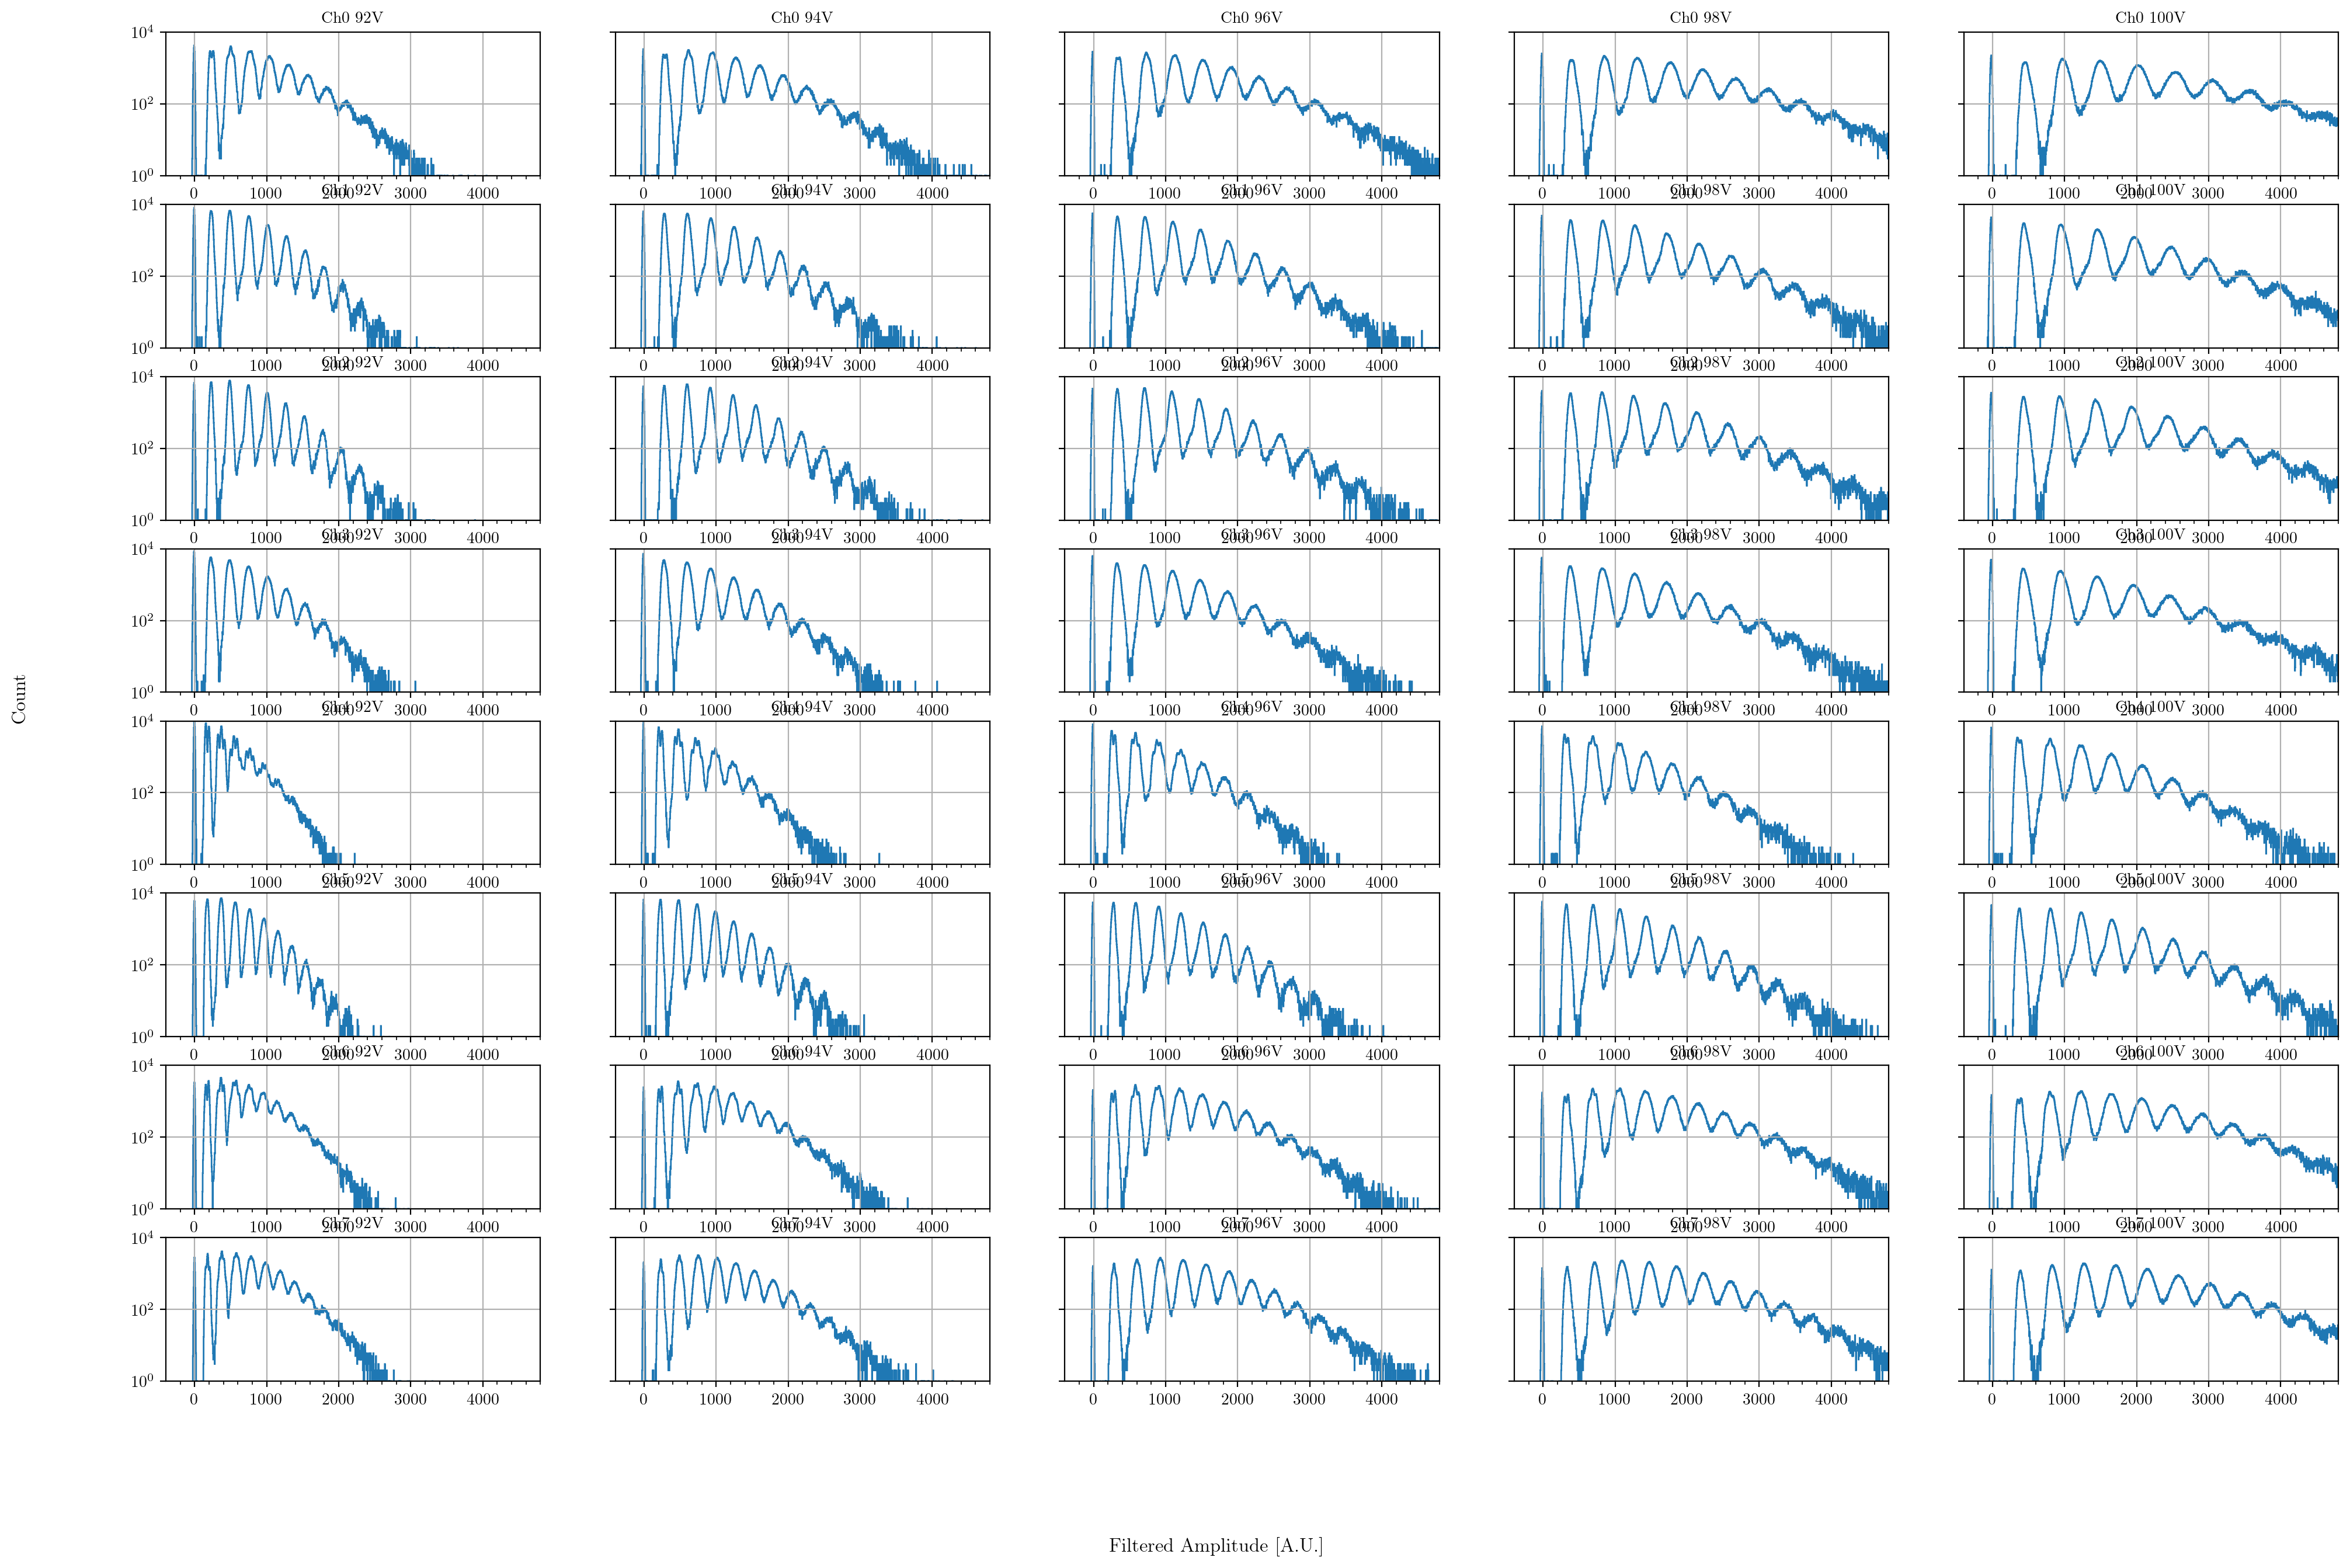

In [27]:
# Make plots for all datasets
# Finger plots
fig, axs = plt.subplots(len(channels), len(voltages), sharex=False, sharey=True)
fig.set_size_inches(3*len(channels), 3*len(voltages))

for j, ch in enumerate(channels):
    for k, volt in enumerate(voltages):
        axs[j,k].stairs(amp_hist[ch][volt]['hist'],
                            amp_hist[ch][volt]['bins'])
        axs[j,k].set_ylim(1, 1e4)
        axs[j,k].set_xlim(amp_hist[ch][volt]['bins'][0]*0.8,
                    amp_hist[ch][volt]['bins'][-1]*0.8)
        axs[j,k].set_yscale('log')
        axs[j,k].minorticks_on()
        axs[j,k].grid()
        axs[j,k].set_title(f'Ch{ch} {volt}V')
fig.supxlabel('Filtered Amplitude [A.U.]', y=0.01)
fig.supylabel('Count', x=0.07)

In [28]:
results = {'dict':{}}
for ch in channels:
    results['dict'][ch] = {}
    for volt in voltages:
        # Do Vinogradov fit
        if 'x' in crosstalk[ch][volt]:
            crosstalk[ch][volt]['par'], crosstalk[ch][volt]['cov'] = curve_fit(
                func.compound_poisson,
                crosstalk[ch][volt]['x'],
                crosstalk[ch][volt]['y'],
                p0=[3, 0.2], sigma=crosstalk[ch][volt]['yerr'], maxfev=10000)
            # Save fit results
            crosstalk[ch][volt]['dict'] = crosstalk[ch][volt]['par'][1]
            crosstalk[ch][volt]['dict_err'] = func.error_distance(df=2, sigma=1)*np.sqrt(crosstalk[ch][volt]['cov'][1, 1])
            print(f'ch{ch} {volt}V P_dict = {crosstalk[ch][volt]["dict"]:.4f} +/- {crosstalk[ch][volt]["dict_err"]:.4f}')
    results['dict'][ch]['bias'] = voltages
    results['dict'][ch]['dict'] = [crosstalk[ch][volt]['dict'] for volt in voltages]
    results['dict'][ch]['dict_err'] = [crosstalk[ch][volt]['dict_err'] for volt in voltages]

ch0 92V P_dict = 0.0271 +/- 0.0039
ch0 94V P_dict = 0.0358 +/- 0.0037
ch0 96V P_dict = 0.0464 +/- 0.0035
ch0 98V P_dict = 0.0627 +/- 0.0025
ch0 100V P_dict = 0.0765 +/- 0.0039
ch1 92V P_dict = 0.0263 +/- 0.0031
ch1 94V P_dict = 0.0366 +/- 0.0029
ch1 96V P_dict = 0.0494 +/- 0.0017
ch1 98V P_dict = 0.0642 +/- 0.0026
ch1 100V P_dict = 0.0747 +/- 0.0056
ch2 92V P_dict = 0.0265 +/- 0.0024
ch2 94V P_dict = 0.0365 +/- 0.0021
ch2 96V P_dict = 0.0499 +/- 0.0022
ch2 98V P_dict = 0.0615 +/- 0.0016
ch2 100V P_dict = 0.0733 +/- 0.0040
ch3 92V P_dict = 0.0246 +/- 0.0028
ch3 94V P_dict = 0.0346 +/- 0.0030
ch3 96V P_dict = 0.0463 +/- 0.0040
ch3 98V P_dict = 0.0641 +/- 0.0028
ch3 100V P_dict = 0.0742 +/- 0.0022
ch4 92V P_dict = 0.0066 +/- 0.0085
ch4 94V P_dict = 0.0223 +/- 0.0014
ch4 96V P_dict = 0.0326 +/- 0.0014
ch4 98V P_dict = 0.0378 +/- 0.0045
ch4 100V P_dict = 0.0480 +/- 0.0048
ch5 92V P_dict = 0.0163 +/- 0.0020
ch5 94V P_dict = 0.0504 +/- 0.0029
ch5 96V P_dict = 0.0581 +/- 0.0027
ch5 98V P_dict 

Text(0.07, 0.5, 'Probability $P_k$')

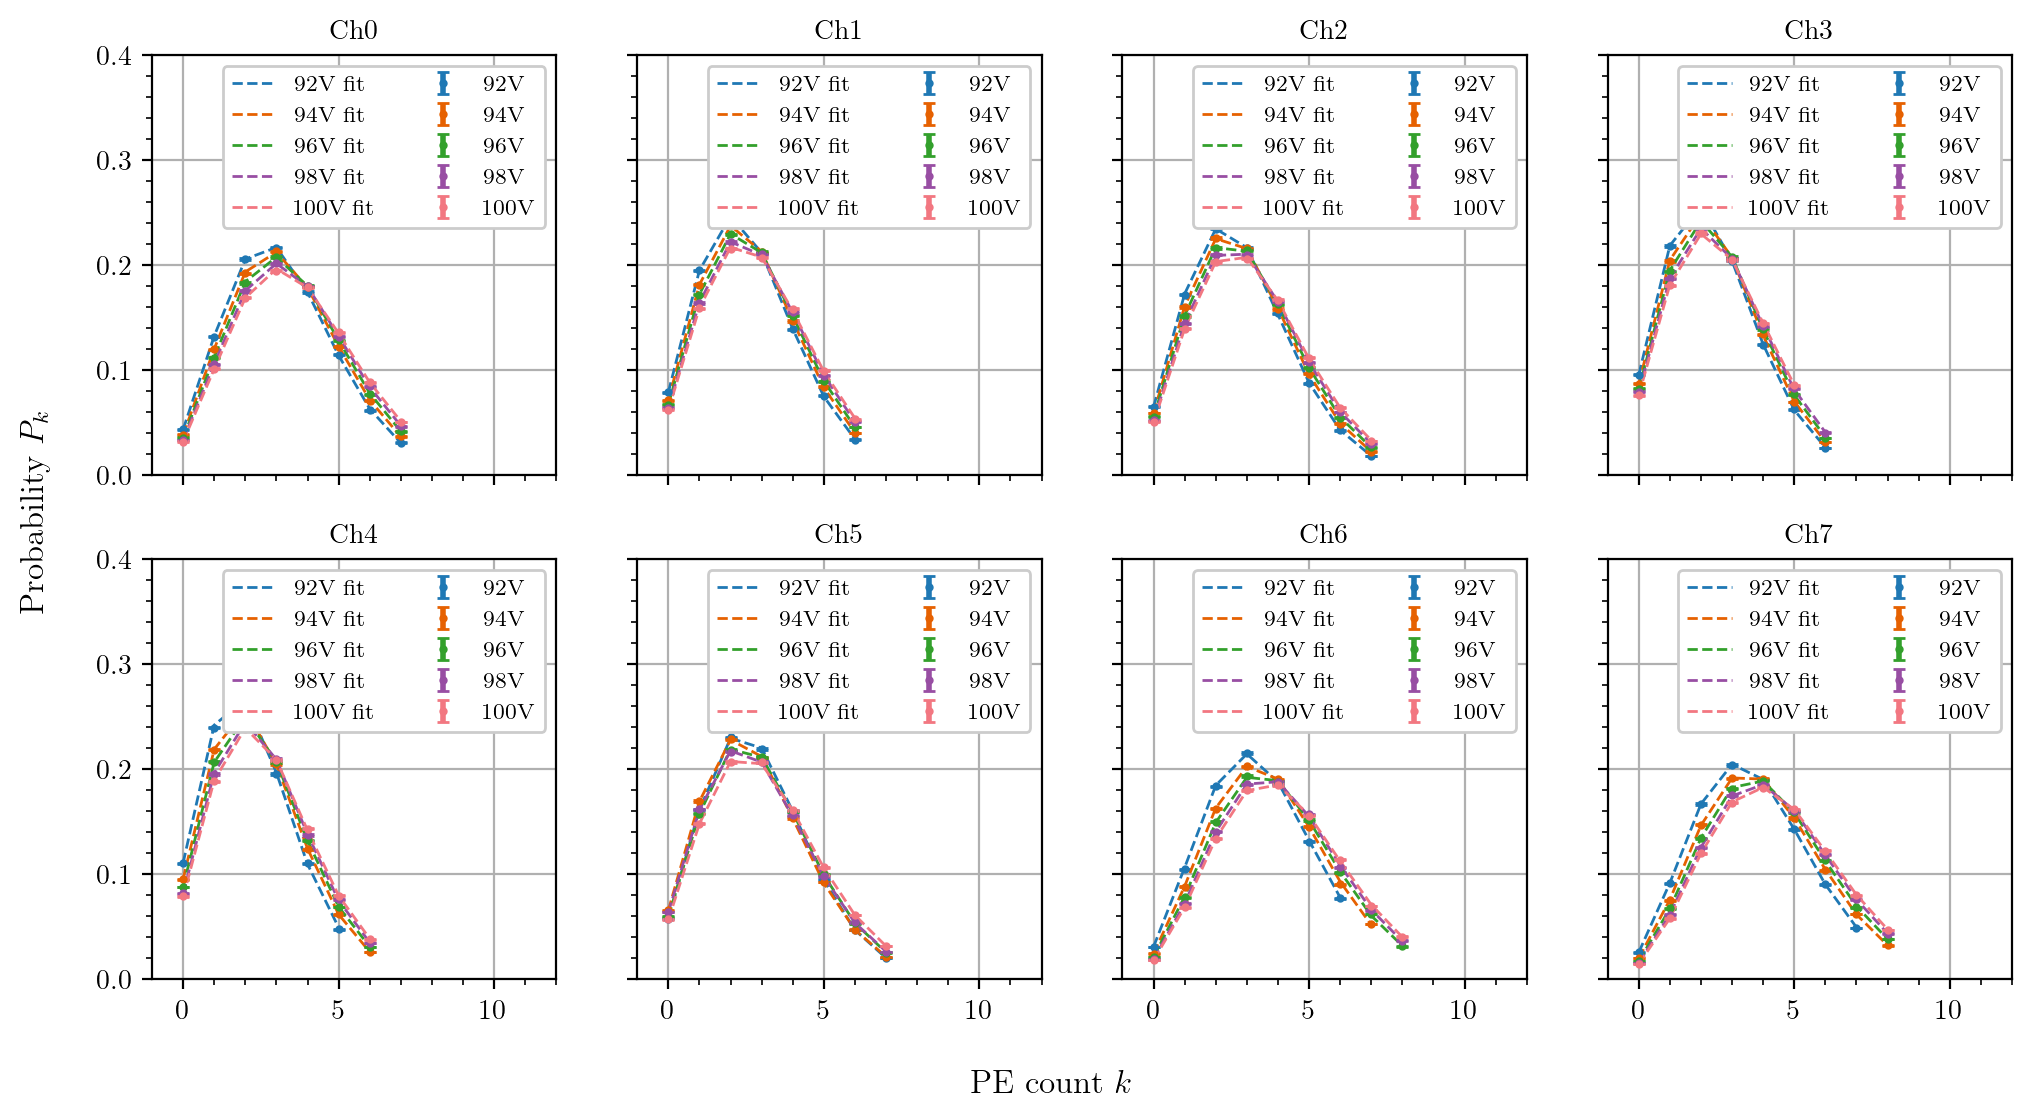

In [29]:
# Make plots for all datasets
# DiCT fits
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    for k, volt in enumerate(voltages):
        if 'x' in crosstalk[ch][volt]:
            axs[j//4,j%4].errorbar(crosstalk[ch][volt]['x'],
                    crosstalk[ch][volt]['y'],
                    yerr=crosstalk[ch][volt]['yerr'],
                    fmt=f'C{k}o', markersize=2, label=f'{volt}V')
            axs[j//4,j%4].plot(crosstalk[ch][volt]['x'],
                        func.compound_poisson(
                            crosstalk[ch][volt]['x'], *crosstalk[ch][volt]['par']),
                        f'C{k}--', label=f'{volt}V fit', linewidth=1)
    axs[j//4,j%4].legend(loc='upper right', ncol=2)
    axs[j//4,j%4].set_ylim(0, 0.4)
    axs[j//4,j%4].set_xlim(-1, 12)
    axs[j//4,j%4].minorticks_on()
    axs[j//4,j%4].grid()
    axs[j//4,j%4].set_title(f'Ch{ch}')
fig.supxlabel(r'PE count $k$', y=0.01)
fig.supylabel(r'Probability $P_k$', x=0.07)

Plots for ch5 100V


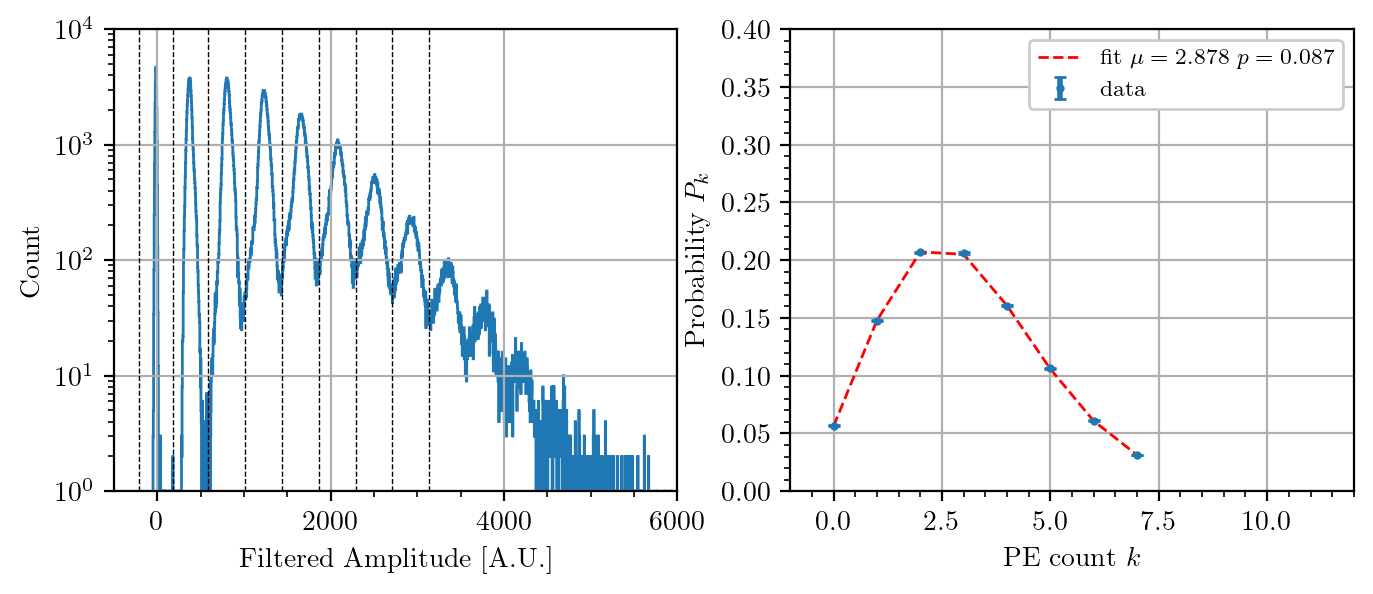

In [30]:
# Make plots for selected datasets
ch = 5
volt = 100
print(f'Plots for ch{ch} {volt}V')
fig, axs = plt.subplots(1, 2)
fig.set_size_inches(8, 3)

# filtered amplitude histogram
axs[0].stairs(amp_hist[ch][volt]['hist'],
              amp_hist[ch][volt]['bins'])
for b in amp_hist[ch][volt]['boundaries']:
    axs[0].plot([b, b], [1, 1e4], 'k--', linewidth=0.5)
axs[0].set_yscale('log')
axs[0].set_xlabel('Filtered Amplitude [A.U.]')
axs[0].set_ylabel('Count')
axs[0].set_xlim(amp_hist[ch][volt]['bins'][0],
                amp_hist[ch][volt]['bins'][-1])
axs[0].set_ylim(1, 1e4)
axs[0].minorticks_on()
axs[0].grid()

# Vinogradov fit
axs[1].errorbar(crosstalk[ch][volt]['x'],
                crosstalk[ch][volt]['y'],
                yerr=crosstalk[ch][volt]['yerr'],
                fmt='o', markersize=2, label='data')
axs[1].plot(crosstalk[ch][volt]['x'],
            func.compound_poisson(
                crosstalk[ch][volt]['x'], *crosstalk[ch][volt]['par']),
            'r--', label=r'fit $\mu={:.3f}$ $p={:.3f}$'.format(*crosstalk[ch][volt]['par']), linewidth=1)
axs[1].set_xlabel(r'PE count $k$')
axs[1].set_ylabel(r'Probability $P_k$')
axs[1].set_ylim(0, 0.4)
axs[1].set_xlim(-1, 12)
axs[1].legend(loc='upper right')
axs[1].minorticks_on()
axs[1].grid()

# Integrated charge and afterpulsing analysis
The integral window is $5~\rm\mu s$ post-trigger and $0.5~\rm \mu s$ pre-trigger.
The integrals are grouped by the PE counts $k$ defined with the filtered amplitude (see previous cell).
The integral distribution has a Gaussian left tail but a heavier right tail due to afterpulses.
The part of the histograms near the peak is fitted by a Gaussian PDF to find the peak position, denoted by $I_{k,\rm peak}$.
$I_{k,\rm peak}$ is linear with $k$, and the slope $Q_{\rm peak}$ is the SPE gain of the SiPMs in arbitrary units.<br>

The average of the histogram, excluding overflowing bins (to reject scintillation events that have very high charge integrals), is denoted by $I_{k,\rm avg}$.
It is also linear with $k$, and the slope is denoted by $Q_{\rm avg}$.
The relative difference, $\frac{Q_{\rm avg}}{Q_{\rm peak}}-1$, is the average afterpulse charge per PE enhanced by DiCT.
Therefore, we define the afterpulse charge as $Q_{\rm AP}=(\frac{Q_{\rm avg}}{Q_{\rm peak}}-1)(1-p)$.<br>

The afterpulse *probability* is also estimated using the fraction of events under the Gaussian (i.e. the normalization of Gaussian function) out of total events.
This fraction is the probability that all $k$ cells have no afterpulse, denoted by $1-P_{\rm AP}(k)$. It should equal to $(1-P_{\rm AP})^k$, where $P_{\rm AP}$ is the afterpulse probability per PE.
$P_{\rm AP}$ extracted from the fits are consistent with $Q_{\rm AP}$, indicating that most afterpulses are a full PE.

The breakdown voltage is obtained by a linear fit to $Q_{\rm peak}$ as a function of bias $V$ using $Q_{\rm peak}=C(V-V_{\rm bd})$.
A comparison of breakdown voltage across channels is further down in the notebook.

## Smearing factor
$v_2 \equiv \frac{Var[n_2|n_1]}{E[n_2|n_1]}$

$n_1$
: prompt PE

$n_2$
: total PE within 5us

In [16]:
charge_hist = {}
charge_fits = {}
ap_prob = {}
fit_range_thre = (0.02, 0.5)
hist_range = (-2e3, 3e4)
nbins = 1000

for ch in channels:
    charge_hist[ch] = {}
    charge_fits[ch] = {}
    ap_prob[ch] = {}
    for volt in voltages:
        charge_hist[ch][volt] = {}
        charge_fits[ch][volt] = {}
        ap_prob[ch][volt] = {}
        range_min = hist_range[0]
        range_max = hist_range[1]+(volt-90)*1e3
        bin_width = (range_max-range_min)/nbins
        for pe in np.arange(1,len(amp_hist[ch][volt]['boundaries'])-1):
            charge_hist[ch][volt][pe] = {}
            charge_fits[ch][volt][pe] = {}
            ap_prob[ch][volt][pe] = {}
            # Generate histograms
            selected_charges = metadata_dict[ch][volt]['data']['integral_5p00us'].loc[(metadata_dict[ch][volt]['data']['bsl_cut'])&(metadata_dict[ch][volt]['data']['pe']==pe)&(metadata_dict[ch][volt]['data']['integral_5p00us']<range_max)&(metadata_dict[ch][volt]['data']['integral_5p00us']>range_min)]
            charge_hist[ch][volt][pe]['hist'], charge_hist[ch][volt][pe]['bins'] = np.histogram(
                selected_charges, bins=nbins, range=(range_min, range_max))
            # find appropriate fit range
            peak_bin = np.argmax(charge_hist[ch][volt][pe]['hist'])
            fit_min = peak_bin
            while charge_hist[ch][volt][pe]['hist'][fit_min] > fit_range_thre[0]*charge_hist[ch][volt][pe]['hist'][peak_bin]:
                fit_min -= 1
            if charge_hist[ch][volt][pe]['hist'][fit_min] == 0:
                fit_min += 1
            charge_fits[ch][volt][pe]['min_bin'] = fit_min
            fit_max = peak_bin
            while charge_hist[ch][volt][pe]['hist'][fit_max] > fit_range_thre[1]*charge_hist[ch][volt][pe]['hist'][peak_bin]:
                fit_max += 1
            if charge_hist[ch][volt][pe]['hist'][fit_max] == 0:
                fit_max -= 1
            charge_fits[ch][volt][pe]['max_bin'] = fit_max
            # Gaussian fits
            charge_fits[ch][volt][pe]['par'], charge_fits[ch][volt][pe]['cov'] = curve_fit(
                func.gauss_normalized,
                0.5*(charge_hist[ch][volt][pe]['bins'][fit_min:fit_max]+charge_hist[ch][volt][pe]['bins'][fit_min+1:fit_max+1]),
                charge_hist[ch][volt][pe]['hist'][fit_min:fit_max],
                p0=[charge_hist[ch][volt][pe]['hist'][peak_bin]*(fit_max-fit_min)*bin_width/3,
                    peak_bin*bin_width+range_min,
                    (fit_max-fit_min)*bin_width/3],
                sigma=np.sqrt(charge_hist[ch][volt][pe]['hist'][fit_min:fit_max]),
                maxfev=100000)
            # Store peak positions and averages
            charge_fits[ch][volt][pe]['Ipeak'] = charge_fits[ch][volt][pe]['par'][1]
            charge_fits[ch][volt][pe]['Ipeak_err'] = func.error_distance(
                df=3, sigma=1)*np.sqrt(charge_fits[ch][volt][pe]['cov'][1, 1])
            charge_fits[ch][volt][pe]['Iavg'] = np.mean(selected_charges)
            charge_fits[ch][volt][pe]['Iavg_err'] = np.std(selected_charges)/np.sqrt(len(selected_charges))
            # Store afterpulse probability
            ap_prob[ch][volt][pe]['prob'] = charge_fits[ch][volt][pe]['par'][0]/bin_width/len(selected_charges)
            ap_prob[ch][volt][pe]['prob_err'] = np.sqrt(ap_prob[ch][volt][pe]['prob']*(1-ap_prob[ch][volt][pe]['prob'])/len(selected_charges))
            # Store variance
            charge_fits[ch][volt][pe]['Ivar'] = np.var(selected_charges)

Text(0.07, 0.5, 'Count')

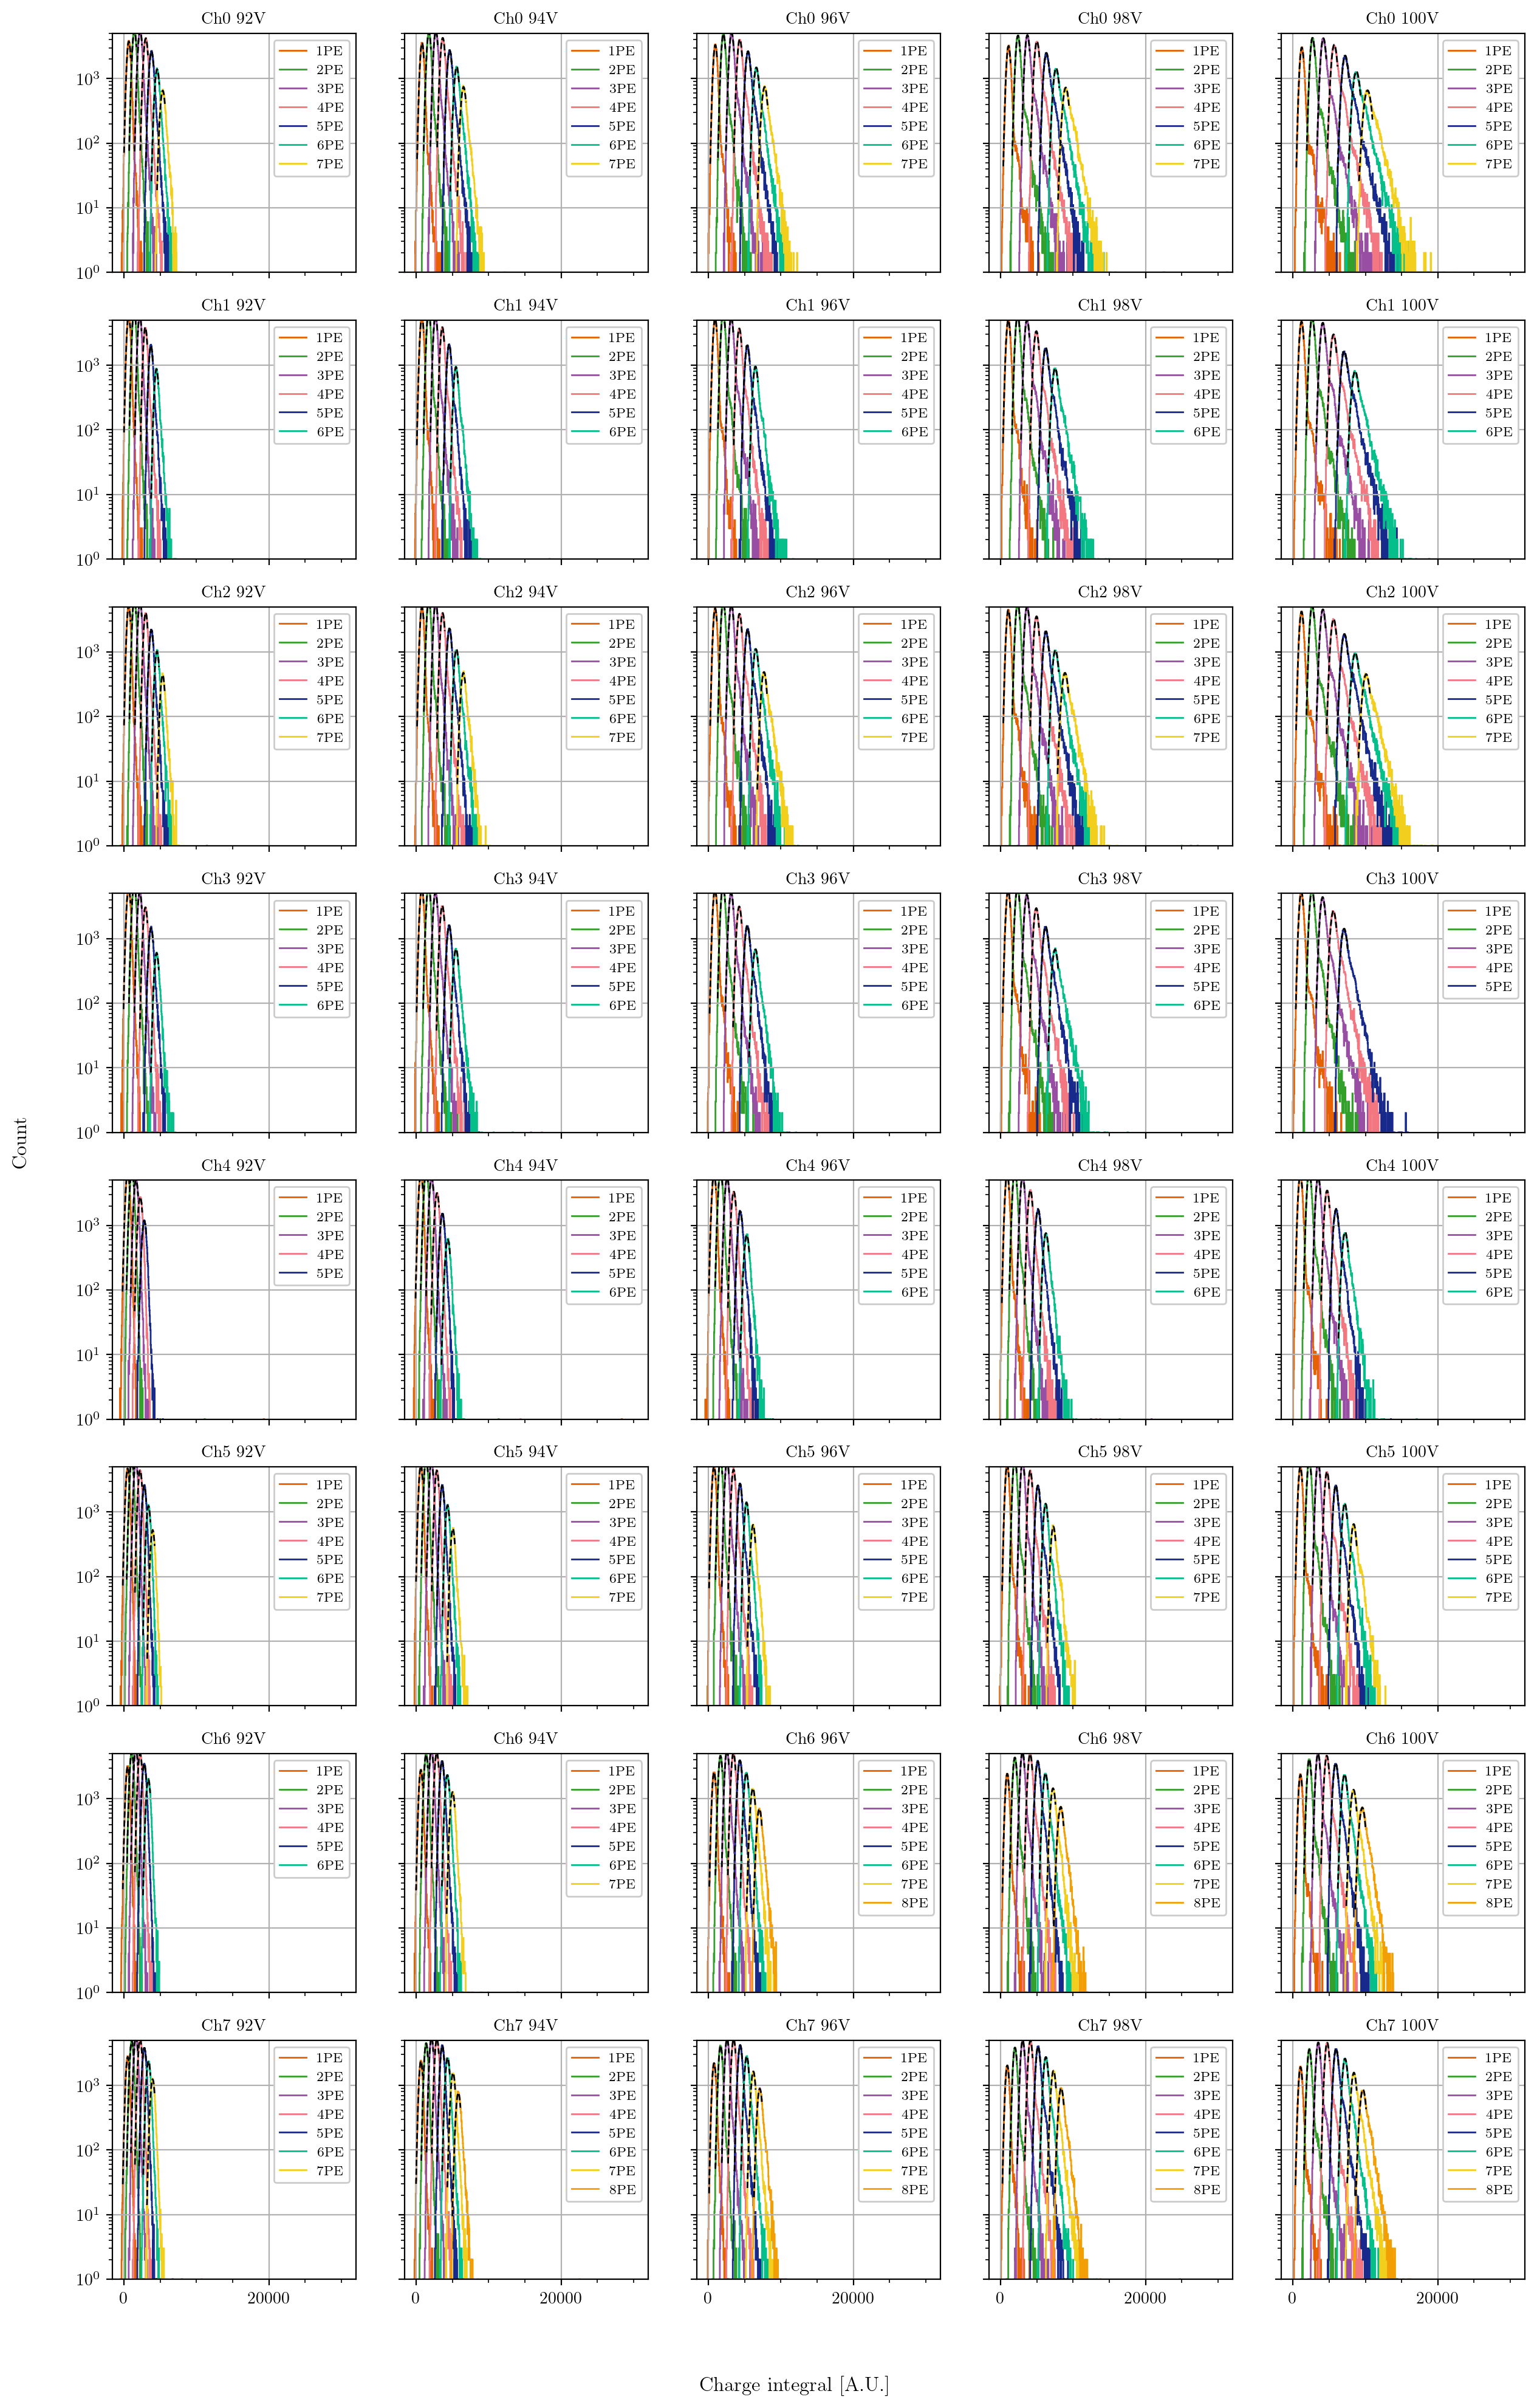

In [17]:
# Make plots for all datasets
# Charge histograms
fig, axs = plt.subplots(len(channels), len(voltages), sharex=True, sharey=True)
fig.set_size_inches(3*len(voltages),3*len(channels))

for j, ch in enumerate(channels):
    for k, volt in enumerate(voltages):
        for pe in charge_hist[ch][volt].keys():
            axs[j, k].stairs(charge_hist[ch][volt][pe]['hist'],
                                    charge_hist[ch][volt][pe]['bins'], label=f'{pe}PE', color=f'C{pe}')
            fit_min = charge_fits[ch][volt][pe]['min_bin']
            fit_max = charge_fits[ch][volt][pe]['max_bin']
            axs[j, k].plot(charge_hist[ch][volt][pe]['bins'][fit_min:fit_max], func.gauss_normalized(
                charge_hist[ch][volt][pe]['bins'][fit_min:fit_max], *charge_fits[ch][volt][pe]['par']), f'k--', linewidth=1)
        axs[j, k].legend(loc='upper right')
        axs[j, k].set_ylim(1, 5e3)
        xmin = charge_hist[ch][volt][list(
            charge_hist[ch][volt].keys())[-1]]['bins'][0]
        xmax = charge_hist[ch][volt][list(
            charge_hist[ch][volt].keys())[-1]]['bins'][-1]
        axs[j, k].set_xlim(xmin*0.8, xmax*0.8)
        axs[j, k].set_yscale('log')
        axs[j, k].minorticks_on()
        axs[j, k].grid()
        axs[j, k].set_title(f'Ch{ch} {volt}V')
fig.supxlabel(r'Charge integral [A.U.]', y=0.07)
fig.supylabel(r'Count', x=0.07)

In [18]:
spe_resolution = {} #SPE CHARGE sigma/mu
for ch in channels:
    spe_resolution[ch] = {}
    for volt in voltages:
        spe_resolution[ch][volt]=charge_fits[ch][volt][1]['par'][2]/charge_fits[ch][volt][1]['par'][1]

Text(0, 0.5, 'SPE Resolution $\\sigma/\\mu$')

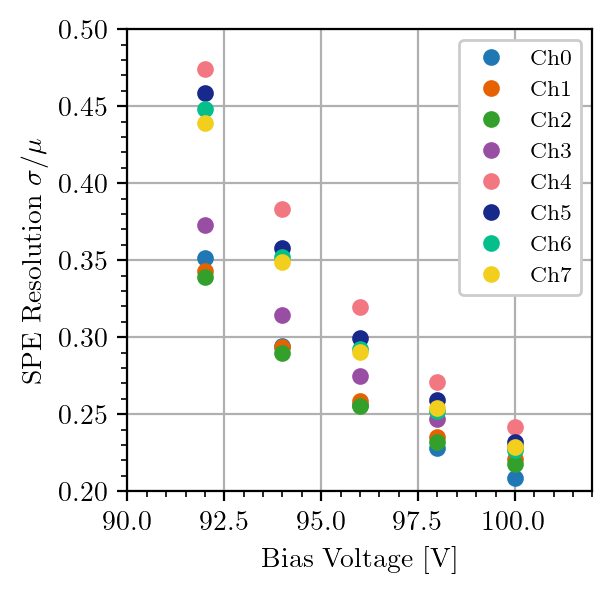

In [19]:
# Make plots for all datasets
# SPE resolution
plt.figure(0,figsize=(3,3))
for j, ch in enumerate(channels):
    plt.plot(voltages,[spe_resolution[ch][volt] for volt in voltages], f'C{j}.', label=f'Ch{ch}')
plt.legend(loc='upper right')
# plt.set_ylim(0, 3e4)
plt.xlim(90, 102)
plt.minorticks_on()
plt.grid()
plt.xlabel('Bias Voltage [V]')
plt.ylabel(r'SPE Resolution $\sigma/\mu$')

In [20]:
gain_peak_fits = {}
gain_avg_fits = {}
results['gain'] = {}
for ch in channels:
    gain_peak_fits[ch] = {}
    gain_avg_fits[ch] = {}
    results['gain'][ch] = {}
    for volt in voltages:
        gain_peak_fits[ch][volt] = {}
        gain_avg_fits[ch][volt] = {}
        # Qpeak fit
        gain_peak_fits[ch][volt]['x'] = np.array(list(charge_fits[ch][volt].keys()))
        gain_peak_fits[ch][volt]['y'] = np.array([charge_fits[ch][volt][pe]['Ipeak'] for pe in charge_fits[ch][volt].keys()])
        gain_peak_fits[ch][volt]['yerr'] = np.array([charge_fits[ch][volt][pe]['Ipeak_err'] for pe in charge_fits[ch][volt].keys()])
        gain_peak_fits[ch][volt]['par'], gain_peak_fits[ch][volt]['cov'] = curve_fit(
            func.line_simple,
            gain_peak_fits[ch][volt]['x'],
            gain_peak_fits[ch][volt]['y'],
            sigma=gain_peak_fits[ch][volt]['yerr'],
            p0=[500, 0],
            maxfev=10000)
        gain_peak_fits[ch][volt]['Qpeak'] = gain_peak_fits[ch][volt]['par'][0]
        gain_peak_fits[ch][volt]['Qpeak_err'] = func.error_distance(df=2, sigma=1)*np.sqrt(gain_peak_fits[ch][volt]['cov'][0, 0])
        # Qavg fit
        gain_avg_fits[ch][volt]['x'] = np.array(list(charge_fits[ch][volt].keys()))
        gain_avg_fits[ch][volt]['y'] = np.array([charge_fits[ch][volt][pe]['Iavg'] for pe in charge_fits[ch][volt].keys()])
        gain_avg_fits[ch][volt]['yerr'] = np.array([charge_fits[ch][volt][pe]['Iavg_err'] for pe in charge_fits[ch][volt].keys()])
        gain_avg_fits[ch][volt]['par'], gain_avg_fits[ch][volt]['cov'] = curve_fit(
            func.line_simple,
            gain_avg_fits[ch][volt]['x'],
            gain_avg_fits[ch][volt]['y'],
            sigma=gain_avg_fits[ch][volt]['yerr'],
            p0=[500, 0],
            maxfev=10000)
        gain_avg_fits[ch][volt]['Qavg'] = gain_avg_fits[ch][volt]['par'][0]
        gain_avg_fits[ch][volt]['Qavg_err'] = func.error_distance(df=2, sigma=1)*np.sqrt(gain_avg_fits[ch][volt]['cov'][0, 0])
    results['gain'][ch]['bias'] = voltages
    results['gain'][ch]['gain'] = [gain_peak_fits[ch][volt]['Qpeak'] for volt in voltages]
    results['gain'][ch]['gain_err'] = [gain_peak_fits[ch][volt]['Qpeak_err'] for volt in voltages]

Text(0.07, 0.5, 'Charge integral $I_k$ [A.U.]')

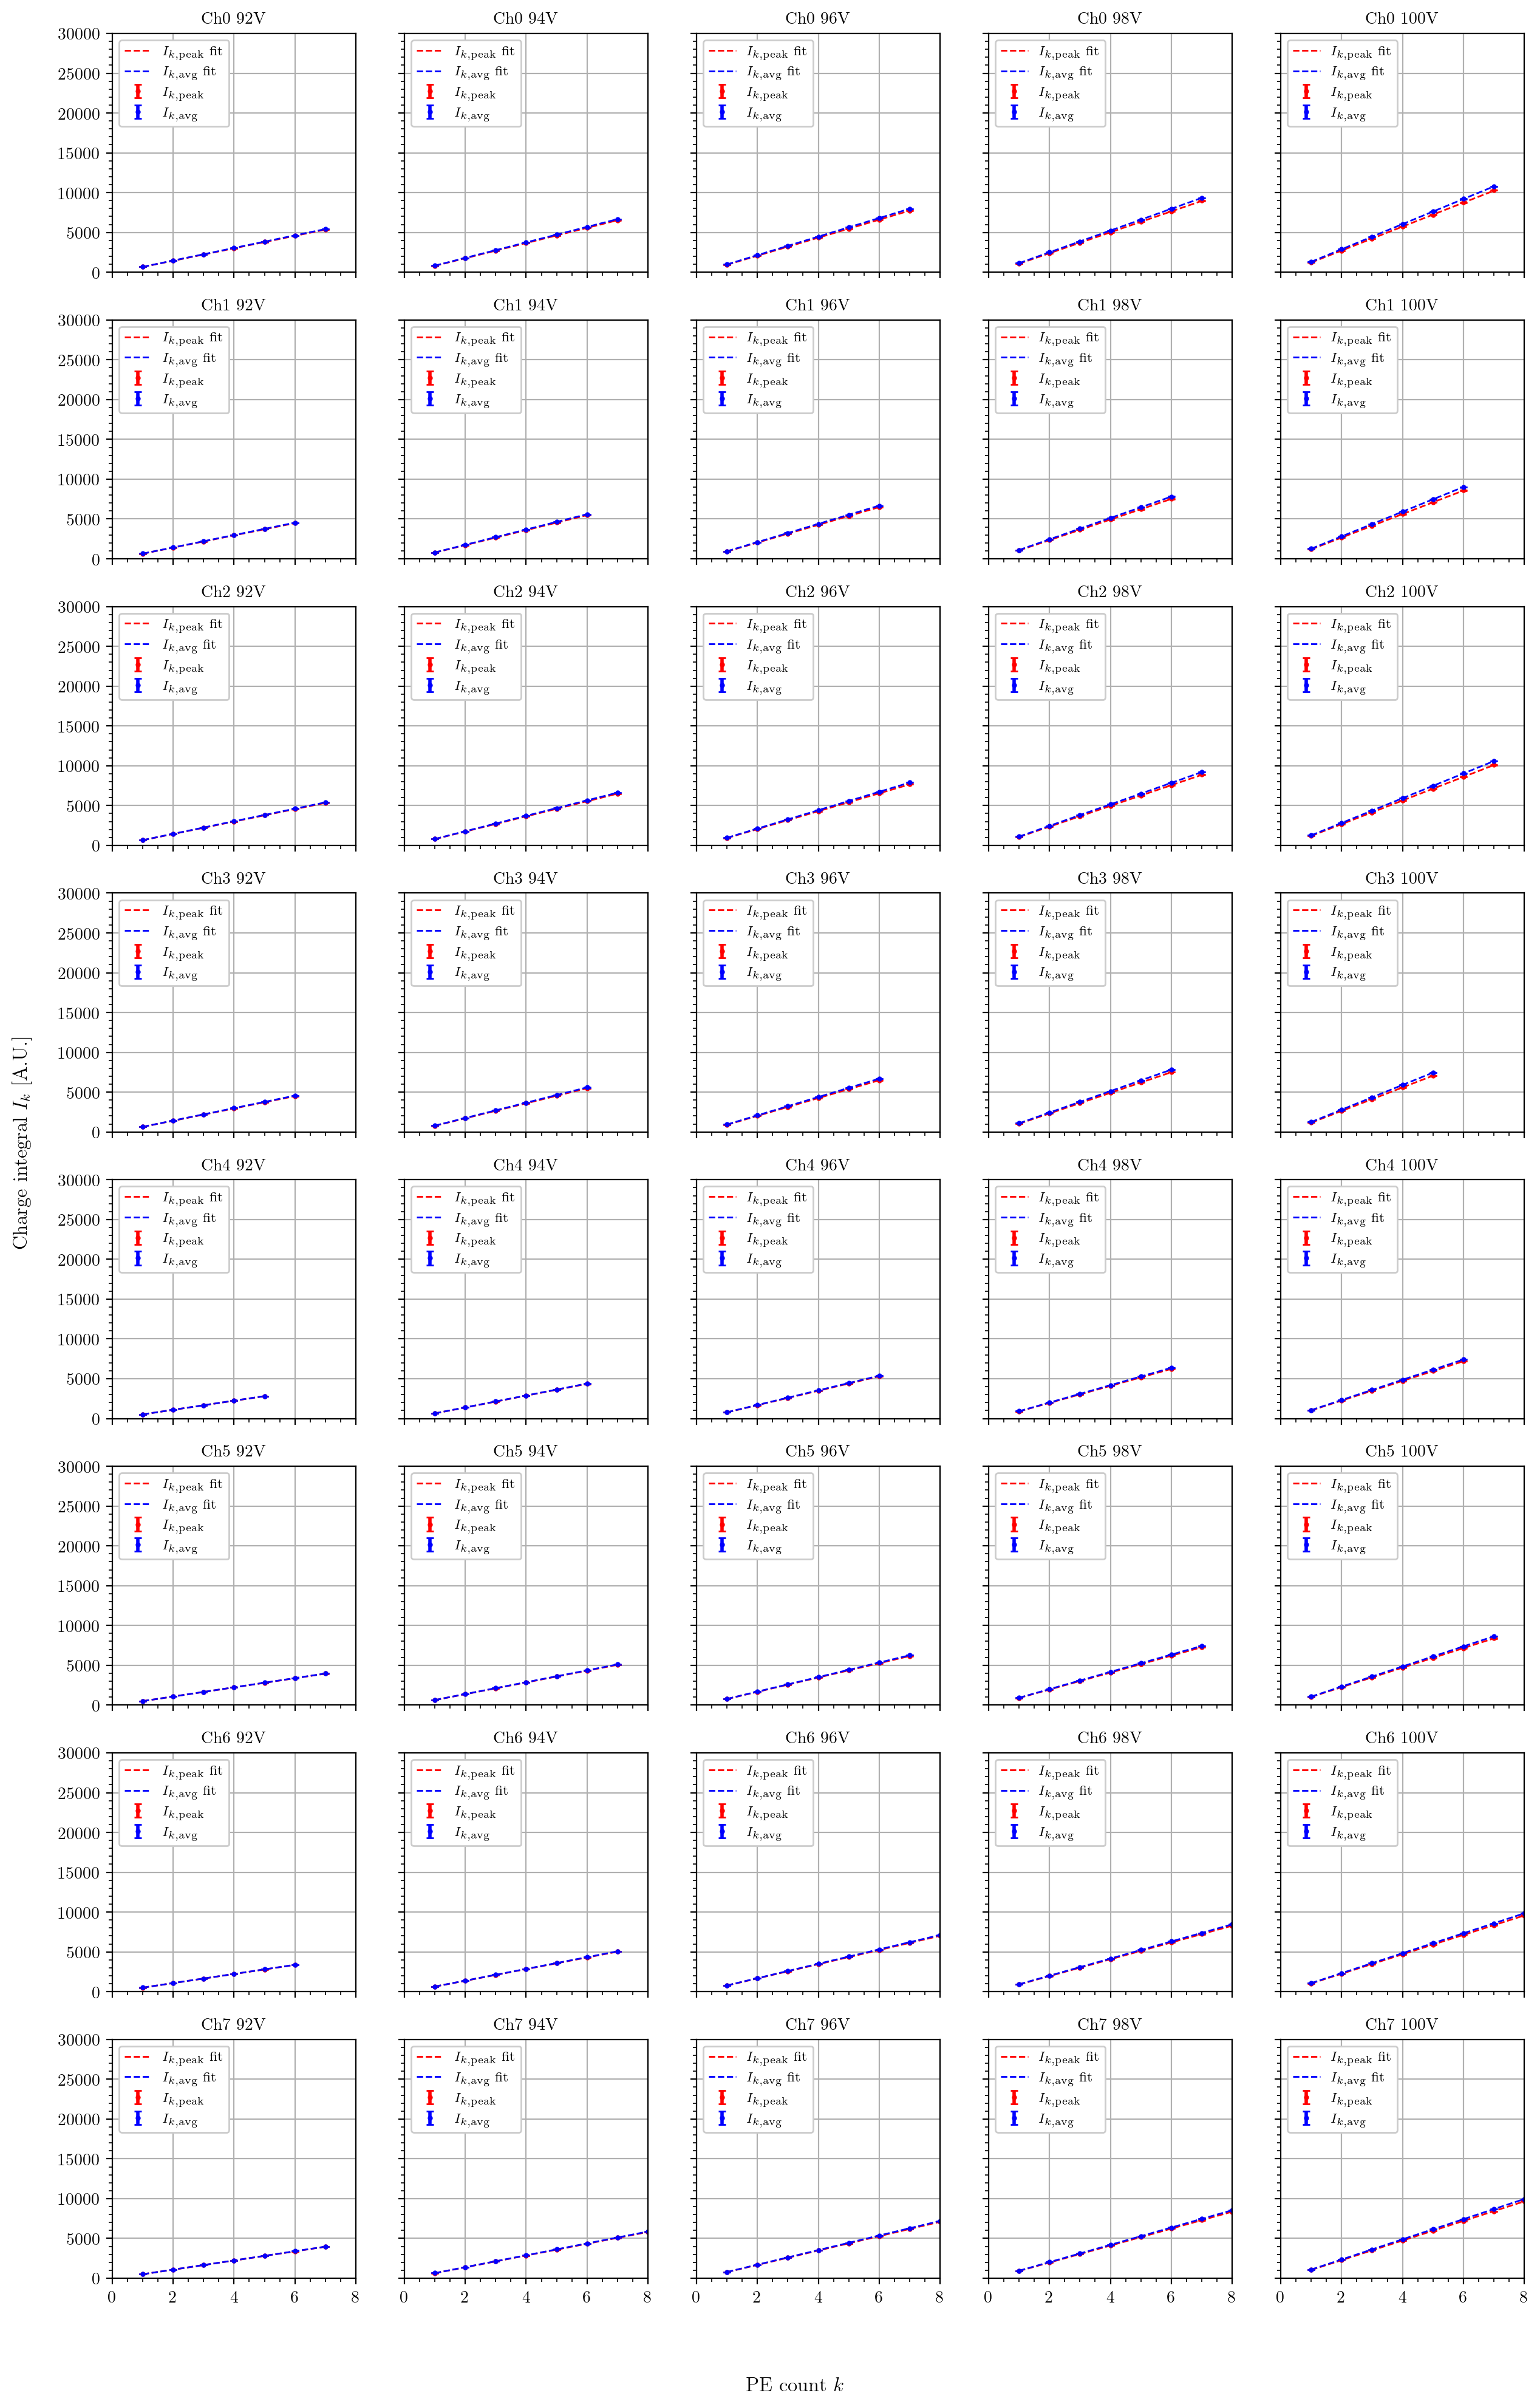

In [21]:
# Make plots for all datasets
# Charge-PE fits
fig, axs = plt.subplots(len(channels), len(voltages), sharex=True, sharey=True)
fig.set_size_inches(3*len(voltages),3*len(channels))
for j, ch in enumerate(channels):
    for k, volt in enumerate(voltages):
        axs[j, k].errorbar(gain_peak_fits[ch][volt]['x'], gain_peak_fits[ch][volt]['y'],
                                yerr=gain_peak_fits[ch][volt]['yerr'], fmt='ro', markersize=2, label=r'$I_{k,\rm peak}$')
        axs[j, k].plot(gain_peak_fits[ch][volt]['x'], func.line_simple(gain_peak_fits[ch][volt]
                            ['x'], *gain_peak_fits[ch][volt]['par']), 'r--', label=r'$I_{k,\rm peak}$ fit', linewidth=1)
        axs[j, k].errorbar(gain_avg_fits[ch][volt]['x'], gain_avg_fits[ch][volt]['y'],
                                yerr=gain_avg_fits[ch][volt]['yerr'], fmt='bo', markersize=2, label=r'$I_{k,\rm avg}$')
        axs[j, k].plot(gain_avg_fits[ch][volt]['x'], func.line_simple(gain_avg_fits[ch][volt]
                            ['x'], *gain_avg_fits[ch][volt]['par']), 'b--', label=r'$I_{k,\rm avg}$ fit', linewidth=1)
        axs[j, k].legend(loc='upper left')
        axs[j, k].set_ylim(0, 3e4)
        axs[j, k].set_xlim(0, 8)
        axs[j, k].minorticks_on()
        axs[j, k].grid()
        axs[j, k].set_title(f'Ch{ch} {volt}V')
fig.supxlabel(r'PE count $k$', y=0.07)
fig.supylabel(r'Charge integral $I_k$ [A.U.]', x=0.07)

In [22]:
ap_charge = {}
ap_prob_fits = {}
results['ap_charge'] = {}
results['ap_prob'] = {}

for ch in channels:
    ap_charge[ch] = {}
    ap_prob_fits[ch] = {}
    results['ap_charge'][ch] = {}
    results['ap_prob'][ch] = {}
    for volt in voltages:
        ap_charge[ch][volt] = {}
        ap_prob_fits[ch][volt] = {}
        # Afterpulse charge
        ap_charge[ch][volt]['Qap'] = gain_avg_fits[ch][volt]['Qavg']/gain_peak_fits[ch][volt]['Qpeak'] - 1
        ap_charge[ch][volt]['Qap_err'] = (1+ap_charge[ch][volt]['Qap'])*np.sqrt((gain_avg_fits[ch][volt]['Qavg_err']/gain_avg_fits[ch][volt]['Qavg'])**2+(gain_peak_fits[ch][volt]['Qpeak_err']/gain_peak_fits[ch][volt]['Qpeak'])**2)
        ap_charge[ch][volt]['Qap'] *= 1-crosstalk[ch][volt]['dict']  # correct for APxDiCT
        ap_charge[ch][volt]['Qap_err'] *= 1-crosstalk[ch][volt]['dict']  # correct for APxDiCT
        # Afterpulse probability fit
        ap_prob_fits[ch][volt]['x'] = np.array(list(ap_prob[ch][volt].keys()))
        ap_prob_fits[ch][volt]['y'] = [ap_prob[ch][volt][pe]['prob'] for pe in ap_prob[ch][volt].keys()]
        ap_prob_fits[ch][volt]['yerr'] = [ap_prob[ch][volt][pe]['prob_err'] for pe in ap_prob[ch][volt].keys()]
        ap_prob_fits[ch][volt]['par'], ap_prob_fits[ch][volt]['cov'] = curve_fit(
            func.power,
            ap_prob_fits[ch][volt]['x'],
            ap_prob_fits[ch][volt]['y'],
            sigma=ap_prob_fits[ch][volt]['yerr'],
            p0=[0.9],
            maxfev=10000)
        ap_prob_fits[ch][volt]['Pap'] = 1-ap_prob_fits[ch][volt]['par'][0]
        ap_prob_fits[ch][volt]['Pap_err'] = func.error_distance(df=1, sigma=1)*np.sqrt(ap_prob_fits[ch][volt]['cov'][0, 0])
    # Qap-Vbias
    results['ap_charge'][ch]['bias'] = voltages
    results['ap_charge'][ch]['ap_charge'] = [ap_charge[ch][volt]['Qap'] for volt in voltages]
    results['ap_charge'][ch]['ap_charge_err'] = [ap_charge[ch][volt]['Qap_err'] for volt in voltages]
    # Pap-Vbias
    results['ap_prob'][ch]['bias'] = voltages
    results['ap_prob'][ch]['ap_prob'] = [ap_prob_fits[ch][volt]['Pap'] for volt in voltages]
    results['ap_prob'][ch]['ap_prob_err'] = [ap_prob_fits[ch][volt]['Pap_err'] for volt in voltages]

Text(0.03, 0.5, '$1-P_{\\rm AP}(k)$')

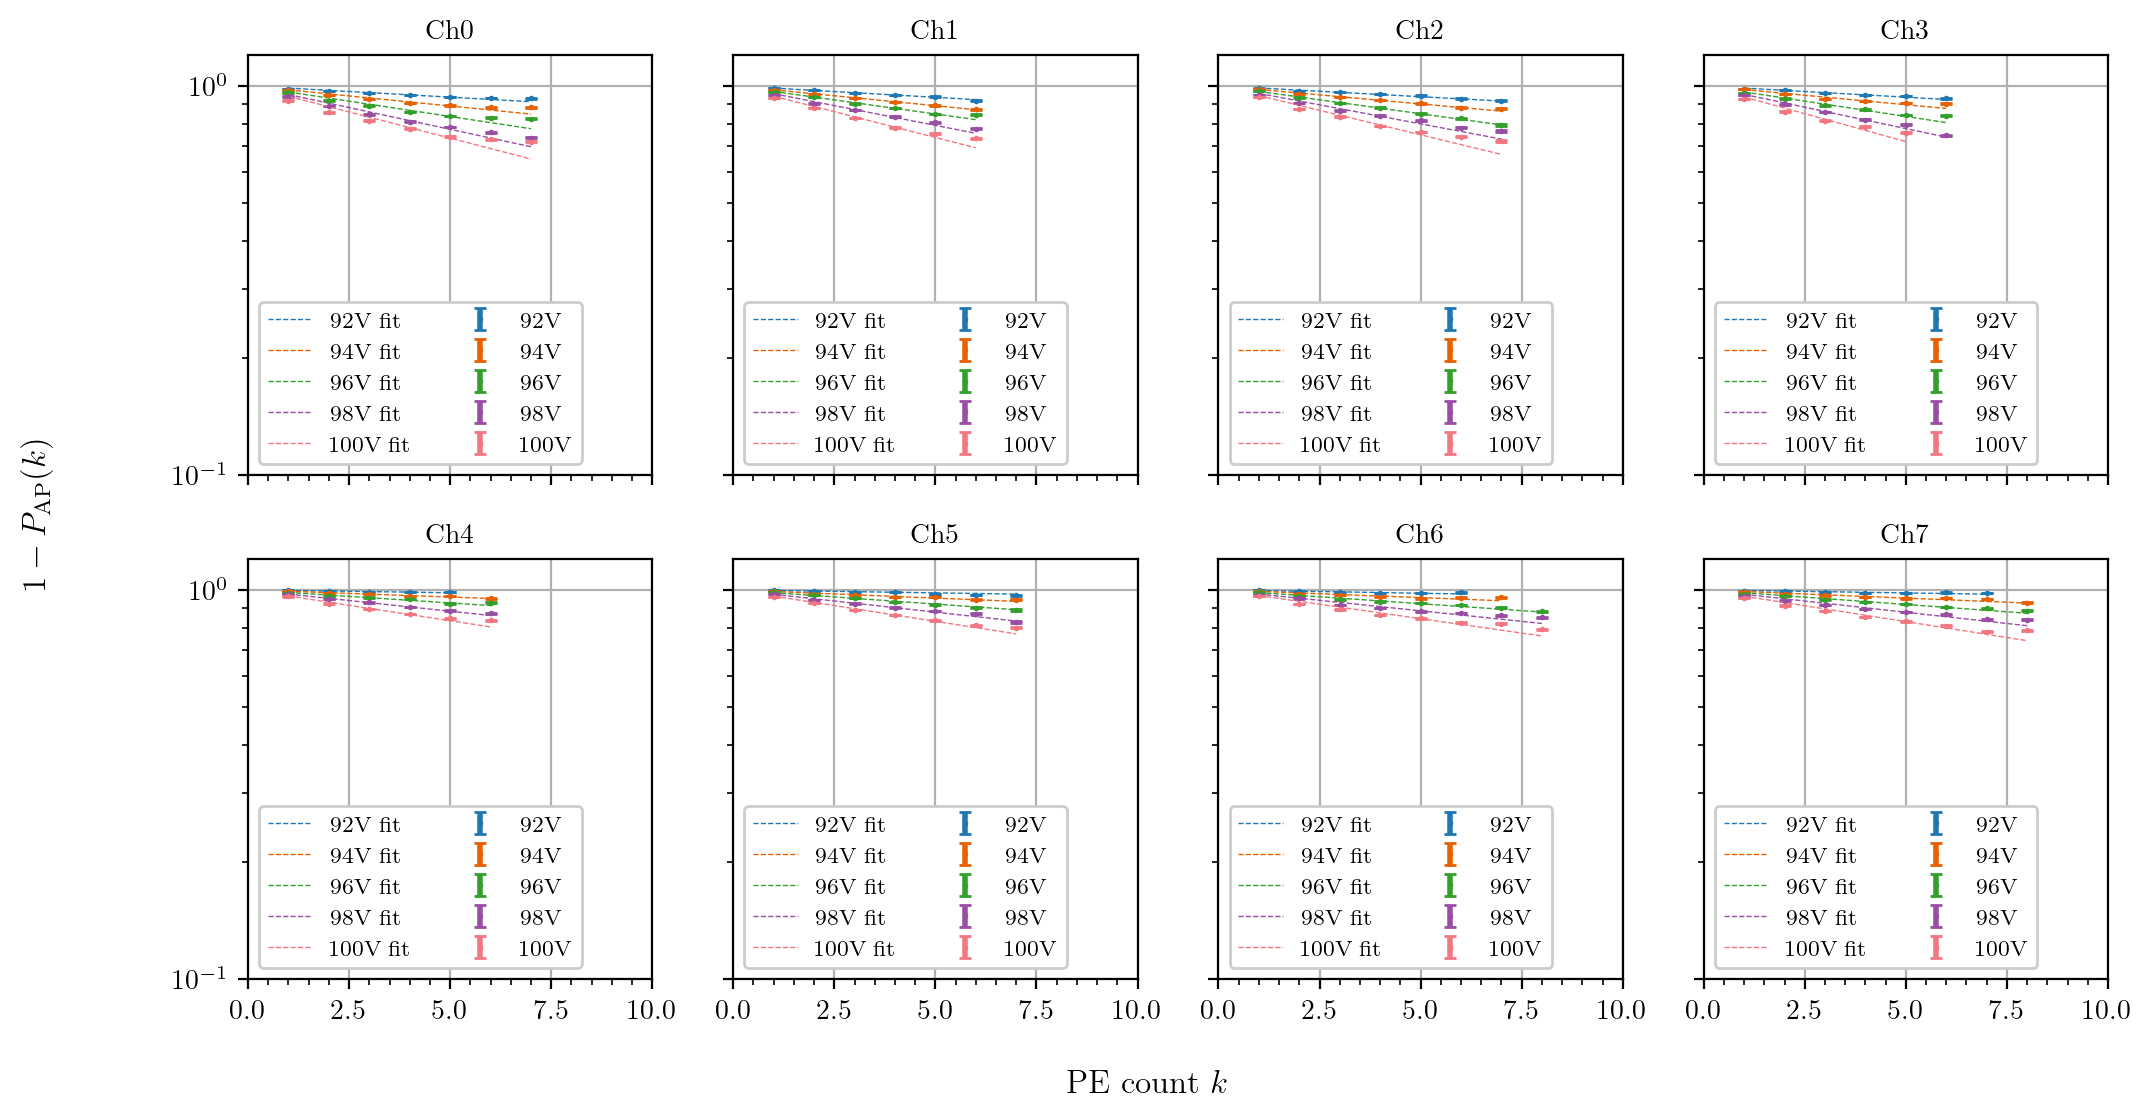

In [23]:
# Make plots for all datasets
# Afterpulse probability fits
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    for k, volt in enumerate(voltages):
        axs[j//4,j%4].errorbar(ap_prob_fits[ch][volt]['x'], ap_prob_fits[ch][volt]['y'],
                            yerr=ap_prob_fits[ch][volt]['yerr'], fmt=f'C{k}o', markersize=1, label=f'{volt}V')
        axs[j//4,j%4].plot(ap_prob_fits[ch][volt]['x'], func.power(ap_prob_fits[ch][volt]['x'],
                        *ap_prob_fits[ch][volt]['par']), f'C{k}--', linewidth=0.5, label=f'{volt}V fit')
    axs[j//4,j%4].legend(loc='lower left', ncol=2)
    axs[j//4,j%4].set_ylim(0.1, 1.2)
    axs[j//4,j%4].set_xlim(0, 10)
    axs[j//4,j%4].set_yscale('log')
    axs[j//4,j%4].minorticks_on()
    axs[j//4,j%4].grid()
    axs[j//4,j%4].set_title(f'Ch{ch}')
fig.supxlabel(r'PE count $k$', y=0.01)
fig.supylabel(r'$1-P_{\rm AP}(k)$', x=0.03)

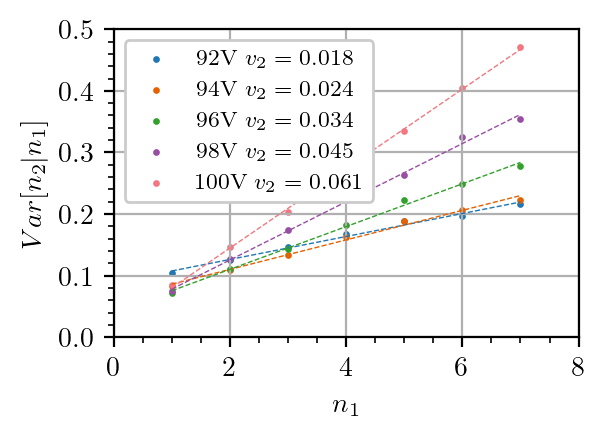

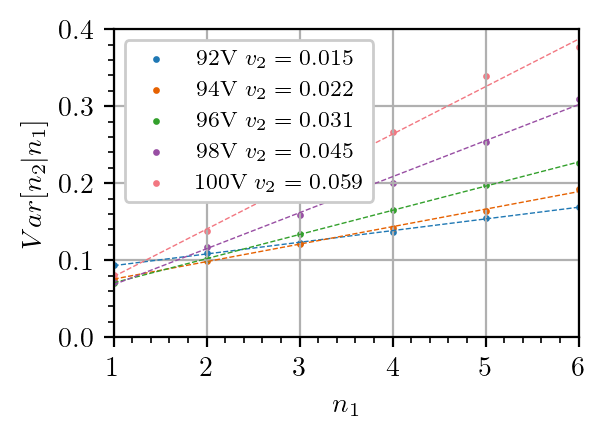

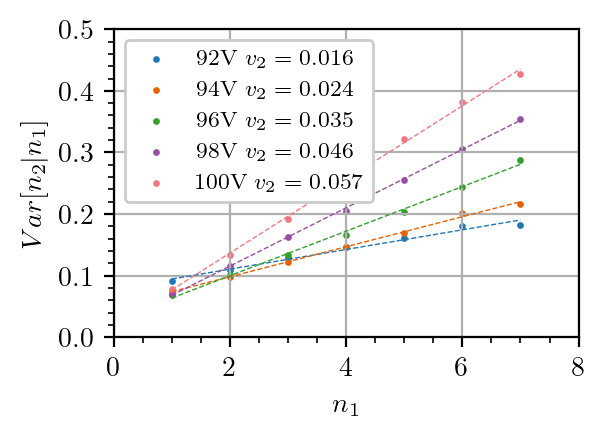

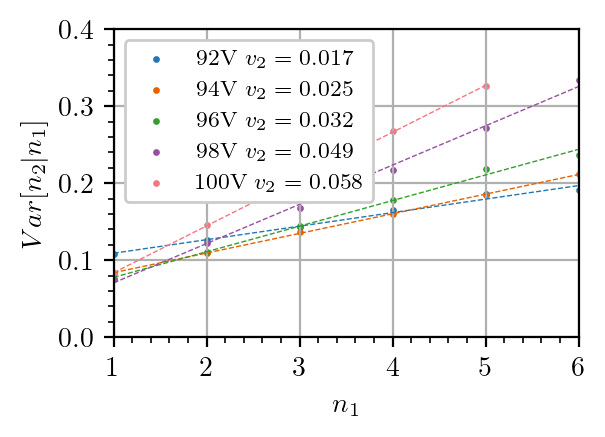

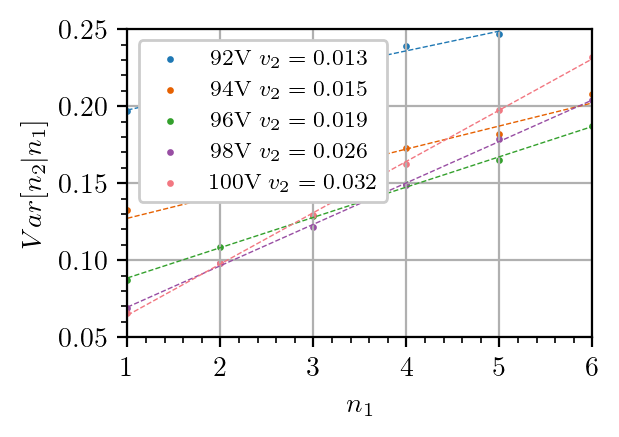

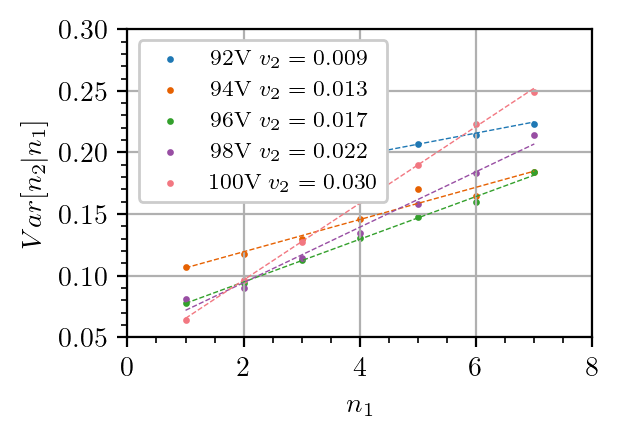

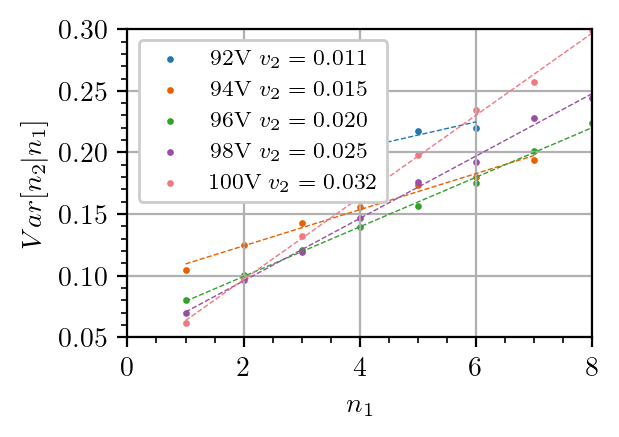

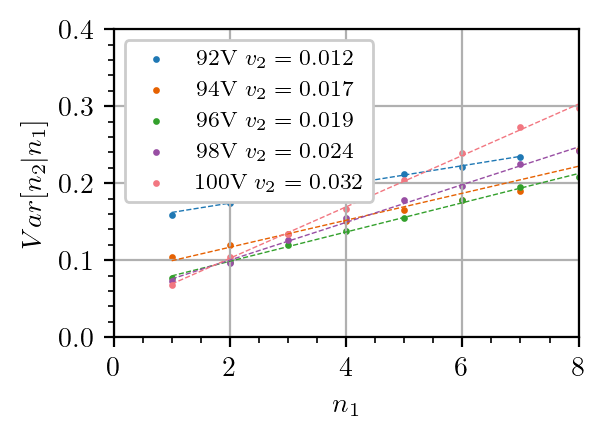

In [24]:
v2_smear = {}
for ch in channels:
    v2_smear[ch] = {}
    plt.figure(ch,figsize=(3,2))
    for iv,volt in enumerate(voltages):
        xdata = [pe for pe in charge_fits[ch][volt].keys()]
        ydata = [charge_fits[ch][volt][pe]['Ivar']/gain_peak_fits[ch][volt]['Qpeak']**2 for pe in charge_fits[ch][volt].keys()]
        par,cov = curve_fit(
            func.line_simple,
            xdata,
            ydata,
            maxfev=10000)
        v2_smear[ch][volt] = par[0]*gain_peak_fits[ch][volt]['Qpeak']/gain_avg_fits[ch][volt]['Qavg']
        plt.scatter(xdata,ydata,label=f'{volt}V '+r'$v_2={:.3f}$'.format(v2_smear[ch][volt]),s=2,c=f'C{iv}')
        xlin = np.linspace(xdata[0],xdata[-1],100)
        plt.plot(xlin,func.line_simple(xlin,*par),f'C{iv}--',linewidth=0.5)
    plt.grid()
    plt.minorticks_on()
    plt.legend()
    plt.xlabel(r'$n_1$')
    plt.ylabel(r'$Var[n_2|n_1]$')

Plots for ch0 96V


(0.0, 1.0, 0.0, 1.0)

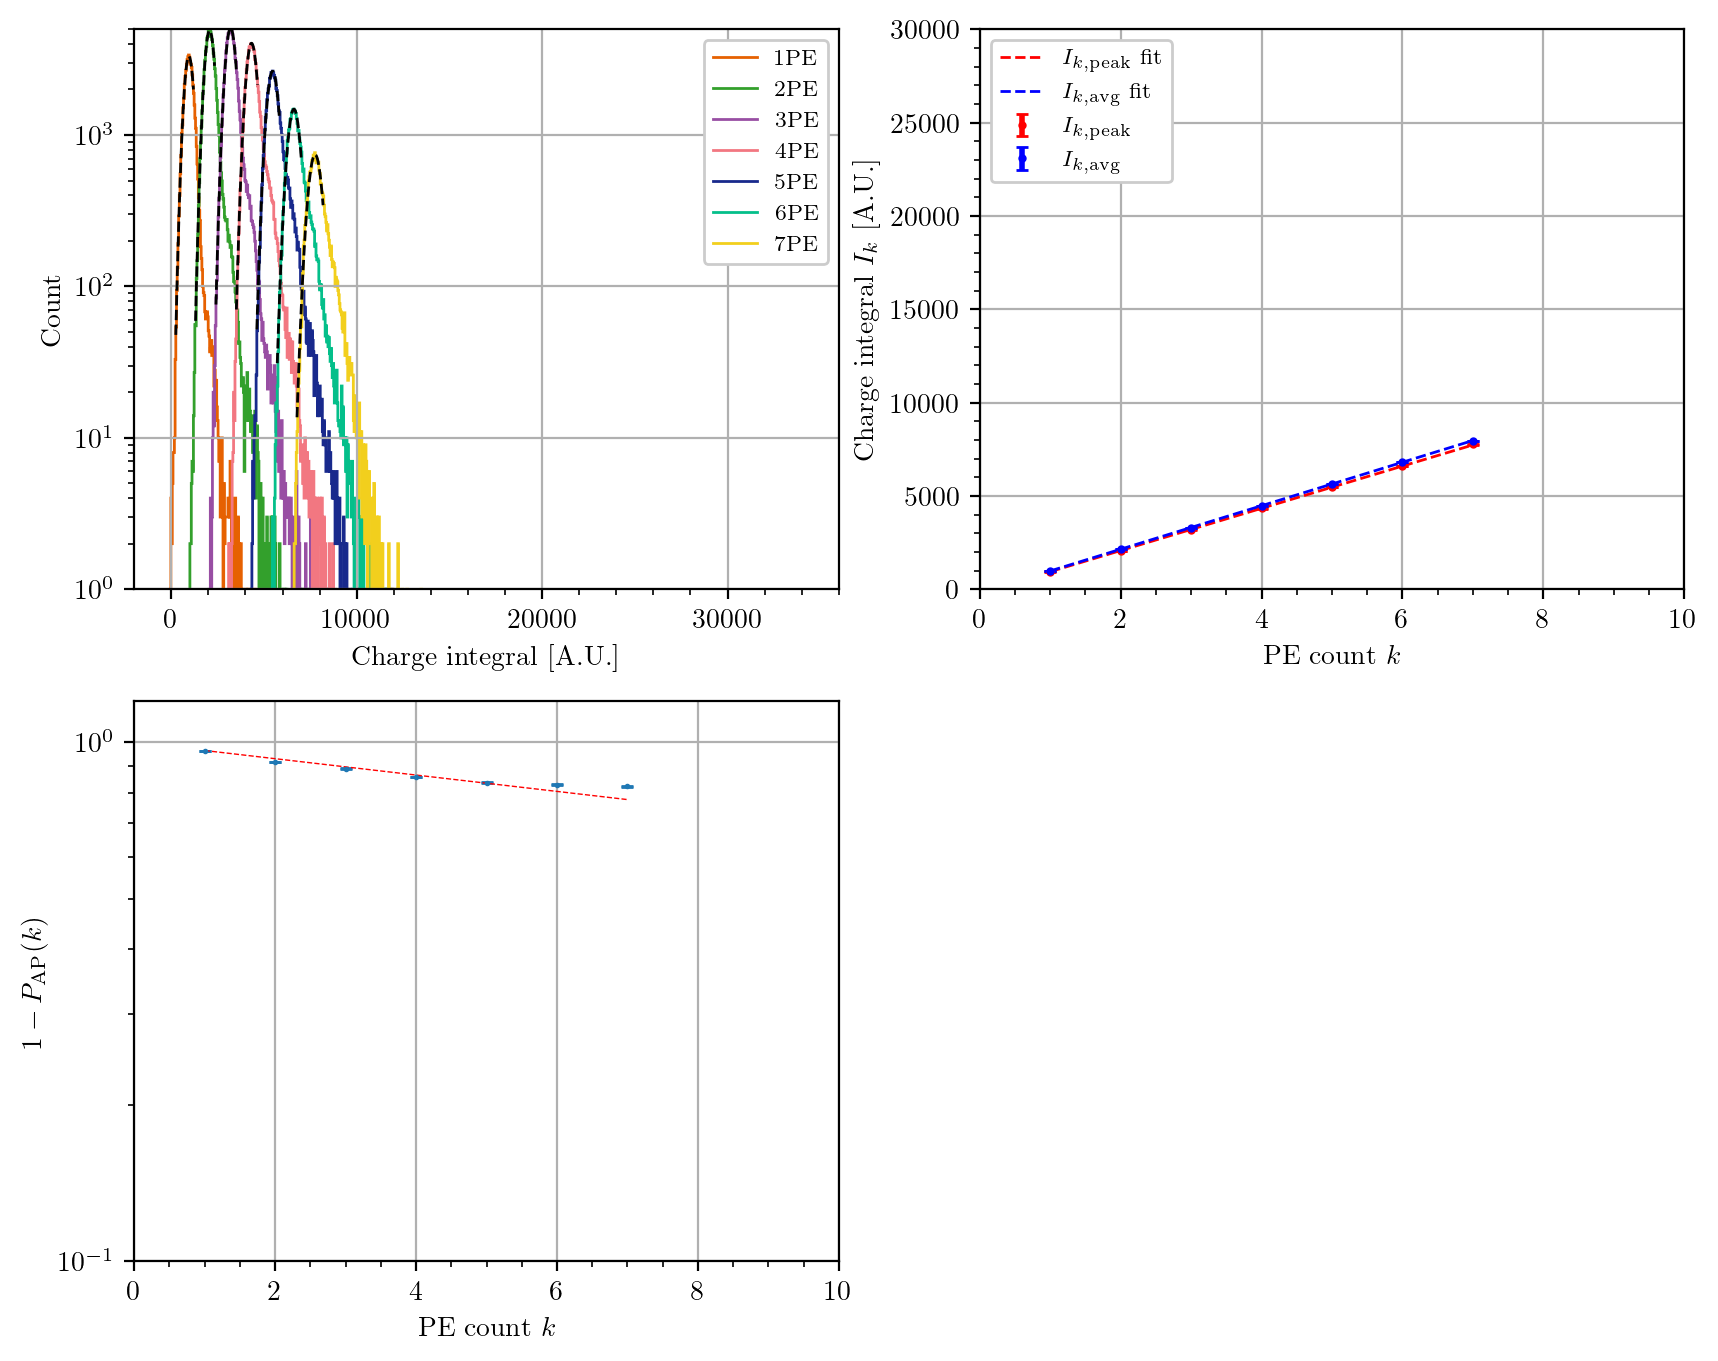

In [25]:
# Make plots for selected datasets
ch = 0
volt = 96
print(f'Plots for ch{ch} {volt}V')
fig, axs = plt.subplots(2, 2)
fig.set_size_inches(10, 8)

# charge histograms
for pe in charge_hist[ch][volt].keys():
    axs[0, 0].stairs(charge_hist[ch][volt][pe]['hist'],
                     charge_hist[ch][volt][pe]['bins'], label=f'{pe}PE', color=f'C{pe}')
    fit_min = charge_fits[ch][volt][pe]['min_bin']
    fit_max = charge_fits[ch][volt][pe]['max_bin']
    axs[0, 0].plot(charge_hist[ch][volt][pe]['bins'][fit_min:fit_max], func.gauss_normalized(
        charge_hist[ch][volt][pe]['bins'][fit_min:fit_max], *charge_fits[ch][volt][pe]['par']), f'k--', linewidth=1)
axs[0, 0].legend(loc='upper right')
axs[0, 0].set_ylim(1, 5e3)
xmin = charge_hist[ch][volt][list(
    charge_hist[ch][volt].keys())[-1]]['bins'][0]
xmax = charge_hist[ch][volt][list(
    charge_hist[ch][volt].keys())[-1]]['bins'][-1]
axs[0, 0].set_xlim(xmin, xmax)
axs[0, 0].set_yscale('log')
axs[0, 0].set_xlabel(r'Charge integral [A.U.]')
axs[0, 0].set_ylabel(r'Count')
axs[0, 0].minorticks_on()
axs[0, 0].grid()

# charge-pe linear fits
axs[0, 1].errorbar(gain_peak_fits[ch][volt]['x'], gain_peak_fits[ch][volt]['y'],
                   yerr=gain_peak_fits[ch][volt]['yerr'], fmt='ro', markersize=2, label=r'$I_{k,\rm peak}$')
axs[0, 1].plot(gain_peak_fits[ch][volt]['x'], func.line_simple(gain_peak_fits[ch][volt]
               ['x'], *gain_peak_fits[ch][volt]['par']), 'r--', label=r'$I_{k,\rm peak}$ fit', linewidth=1)
axs[0, 1].errorbar(gain_avg_fits[ch][volt]['x'], gain_avg_fits[ch][volt]['y'],
                   yerr=gain_avg_fits[ch][volt]['yerr'], fmt='bo', markersize=2, label=r'$I_{k,\rm avg}$')
axs[0, 1].plot(gain_avg_fits[ch][volt]['x'], func.line_simple(gain_avg_fits[ch][volt]
               ['x'], *gain_avg_fits[ch][volt]['par']), 'b--', label=r'$I_{k,\rm avg}$ fit', linewidth=1)
axs[0, 1].legend()
axs[0, 1].set_xlabel(r'PE count $k$')
axs[0, 1].set_ylabel(r'Charge integral $I_k$ [A.U.]')
axs[0, 1].set_xlim(0, 10)
axs[0, 1].set_ylim(0, 3e4)
axs[0, 1].legend()
axs[0, 1].grid()
axs[0, 1].minorticks_on()

# afterpulse probability
axs[1, 0].errorbar(ap_prob_fits[ch][volt]['x'],
                   ap_prob_fits[ch][volt]['y'],
                   yerr=ap_prob_fits[ch][volt]['yerr'],
                   fmt='o',
                   markersize=1)
axs[1, 0].plot(ap_prob_fits[ch][volt]['x'],
               func.power(ap_prob_fits[ch][volt]['x'],
                          *ap_prob_fits[ch][volt]['par']),
               'r--',
               linewidth=0.5)
axs[1, 0].set_xlim(0, 10)
axs[1, 0].set_ylim(0.1, 1.2)
axs[1, 0].set_yscale('log')
axs[1, 0].minorticks_on()
axs[1, 0].grid()
axs[1, 0].set_xlabel(r'PE count $k$')
axs[1, 0].set_ylabel(r'$1-P_{\rm AP}(k)$')

# empty figure
axs[1, 1].axis('off')

In [26]:
nsipms = 2
vbd_fits = {}
results['vbd'] = {}
init_pars=[100,55]
for ch in channels:
    vbd_fits[ch] = {}
    results['vbd'][ch] = {}
    vbd_fits[ch]['x'] = voltages
    vbd_fits[ch]['y'] = [gain_peak_fits[ch][volt]['Qpeak'] for volt in voltages]
    vbd_fits[ch]['yerr'] = [gain_peak_fits[ch][volt]['Qpeak_err'] for volt in voltages]
    vbd_fits[ch]['par'], vbd_fits[ch]['cov'] = curve_fit(
        func.line,
        vbd_fits[ch]['x'],
        vbd_fits[ch]['y'],
        sigma=vbd_fits[ch]['yerr'],
        p0=init_pars,
        maxfev=10000)
    vbd_fits[ch]['vbd'] = vbd_fits[ch]['par'][1]
    vbd_fits[ch]['vbd_err'] = func.error_distance(df=2, sigma=1)*np.sqrt(vbd_fits[ch]['cov'][1, 1])
    print(f'ch{ch} Vbd = {vbd_fits[ch]["vbd"]:.2f} +/- {vbd_fits[ch]["vbd_err"]:.2f} V')
    results['vbd'][ch]['vbd_sipm'] = vbd_fits[ch]['vbd']/nsipms
    results['vbd'][ch]['vbd_sipm_err'] = vbd_fits[ch]['vbd_err']/nsipms
    results['dict'][ch]['ov'] = np.array(results['dict'][ch]['bias'])/nsipms-results['vbd'][ch]['vbd_sipm']
    results['dict'][ch]['ov_err'] = np.ones(results['dict'][ch]['ov'].shape[0])*results['vbd'][ch]['vbd_sipm_err']
    results['ap_charge'][ch]['ov'] = np.array(results['ap_charge'][ch]['bias'])/nsipms-results['vbd'][ch]['vbd_sipm']
    results['ap_charge'][ch]['ov_err'] = np.ones(results['ap_charge'][ch]['ov'].shape[0])*results['vbd'][ch]['vbd_sipm_err']
    results['ap_prob'][ch]['ov'] = np.array(results['ap_prob'][ch]['bias'])/nsipms-results['vbd'][ch]['vbd_sipm']
    results['ap_prob'][ch]['ov_err'] = np.ones(results['ap_prob'][ch]['ov'].shape[0])*results['vbd'][ch]['vbd_sipm_err']
    results['gain'][ch]['ov'] = np.array(results['gain'][ch]['bias'])/nsipms-results['vbd'][ch]['vbd_sipm']
    results['gain'][ch]['ov_err'] = np.ones(results['gain'][ch]['ov'].shape[0])*results['vbd'][ch]['vbd_sipm_err']

ch0 Vbd = 83.21 +/- 0.16 V
ch1 Vbd = 83.28 +/- 0.15 V
ch2 Vbd = 83.03 +/- 0.18 V
ch3 Vbd = 83.19 +/- 0.13 V
ch4 Vbd = 85.06 +/- 0.09 V
ch5 Vbd = 84.94 +/- 0.04 V
ch6 Vbd = 84.96 +/- 0.07 V
ch7 Vbd = 84.96 +/- 0.08 V


(0.0, 5000.0)

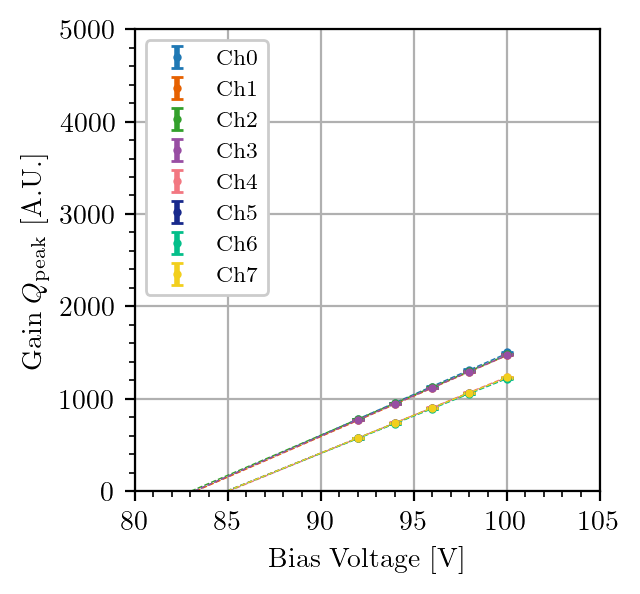

In [27]:
# Make plots for all datasets
# Gain-Vbias linear fits
fig, ax = plt.subplots(1)
fig.set_size_inches(3, 3)
for ch in channels:
    ax.errorbar(vbd_fits[ch]['x'],
                vbd_fits[ch]['y'],
                yerr=vbd_fits[ch]['yerr'],
                label=f'Ch{ch}', fmt='C{}o'.format(ch), markersize=2)
    ax.plot(sorted(voltages + [vbd_fits[ch]['vbd']]),
            func.line(np.array(sorted(voltages + [vbd_fits[ch]['vbd']])), *vbd_fits[ch]['par']),
            '--', linewidth=0.5)
ax.legend(loc='upper left')
ax.set_xlabel('Bias Voltage [V]')
ax.set_ylabel(r'Gain $Q_{\rm peak}$ [A.U.]')
ax.grid()
ax.minorticks_on()
ax.set_xlim(80, 105)
ax.set_ylim(0, 5.0e3)


Plots for ch2


(0.0, 5000.0)

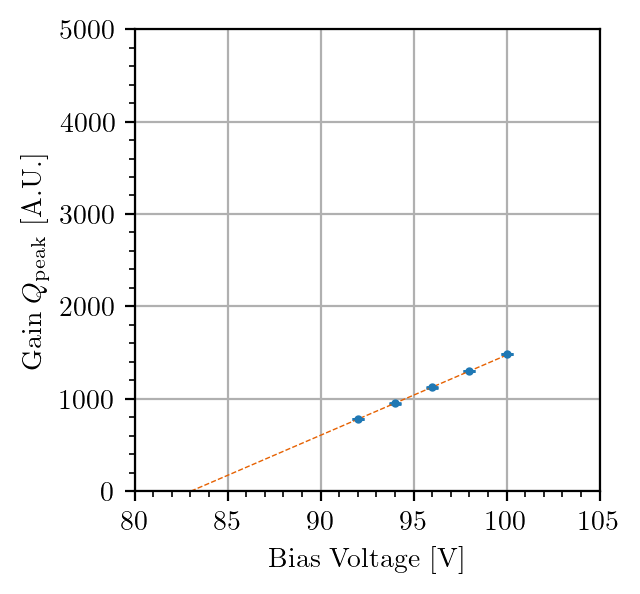

In [28]:
# Make plots for selected datasets
ch = 2
print(f'Plots for ch{ch}')
fig, ax = plt.subplots(1)
fig.set_size_inches(3, 3)
# Gain-Vbias linear fits
ax.errorbar(vbd_fits[ch]['x'],
            vbd_fits[ch]['y'],
            yerr=vbd_fits[ch]['yerr'],
            label=f'ch{ch}', fmt='o', markersize=2)
ax.plot(sorted(voltages + [vbd_fits[ch]['vbd']]),
        func.line(np.array(sorted(voltages + [vbd_fits[ch]['vbd']])), *vbd_fits[ch]['par']),
        '--', linewidth=0.5)
ax.set_xlabel('Bias Voltage [V]')
ax.set_ylabel(r'Gain $Q_{\rm peak}$ [A.U.]')
ax.grid()
ax.minorticks_on()
ax.set_xlim(80, 105)
ax.set_ylim(0, 5e3)


# Summary

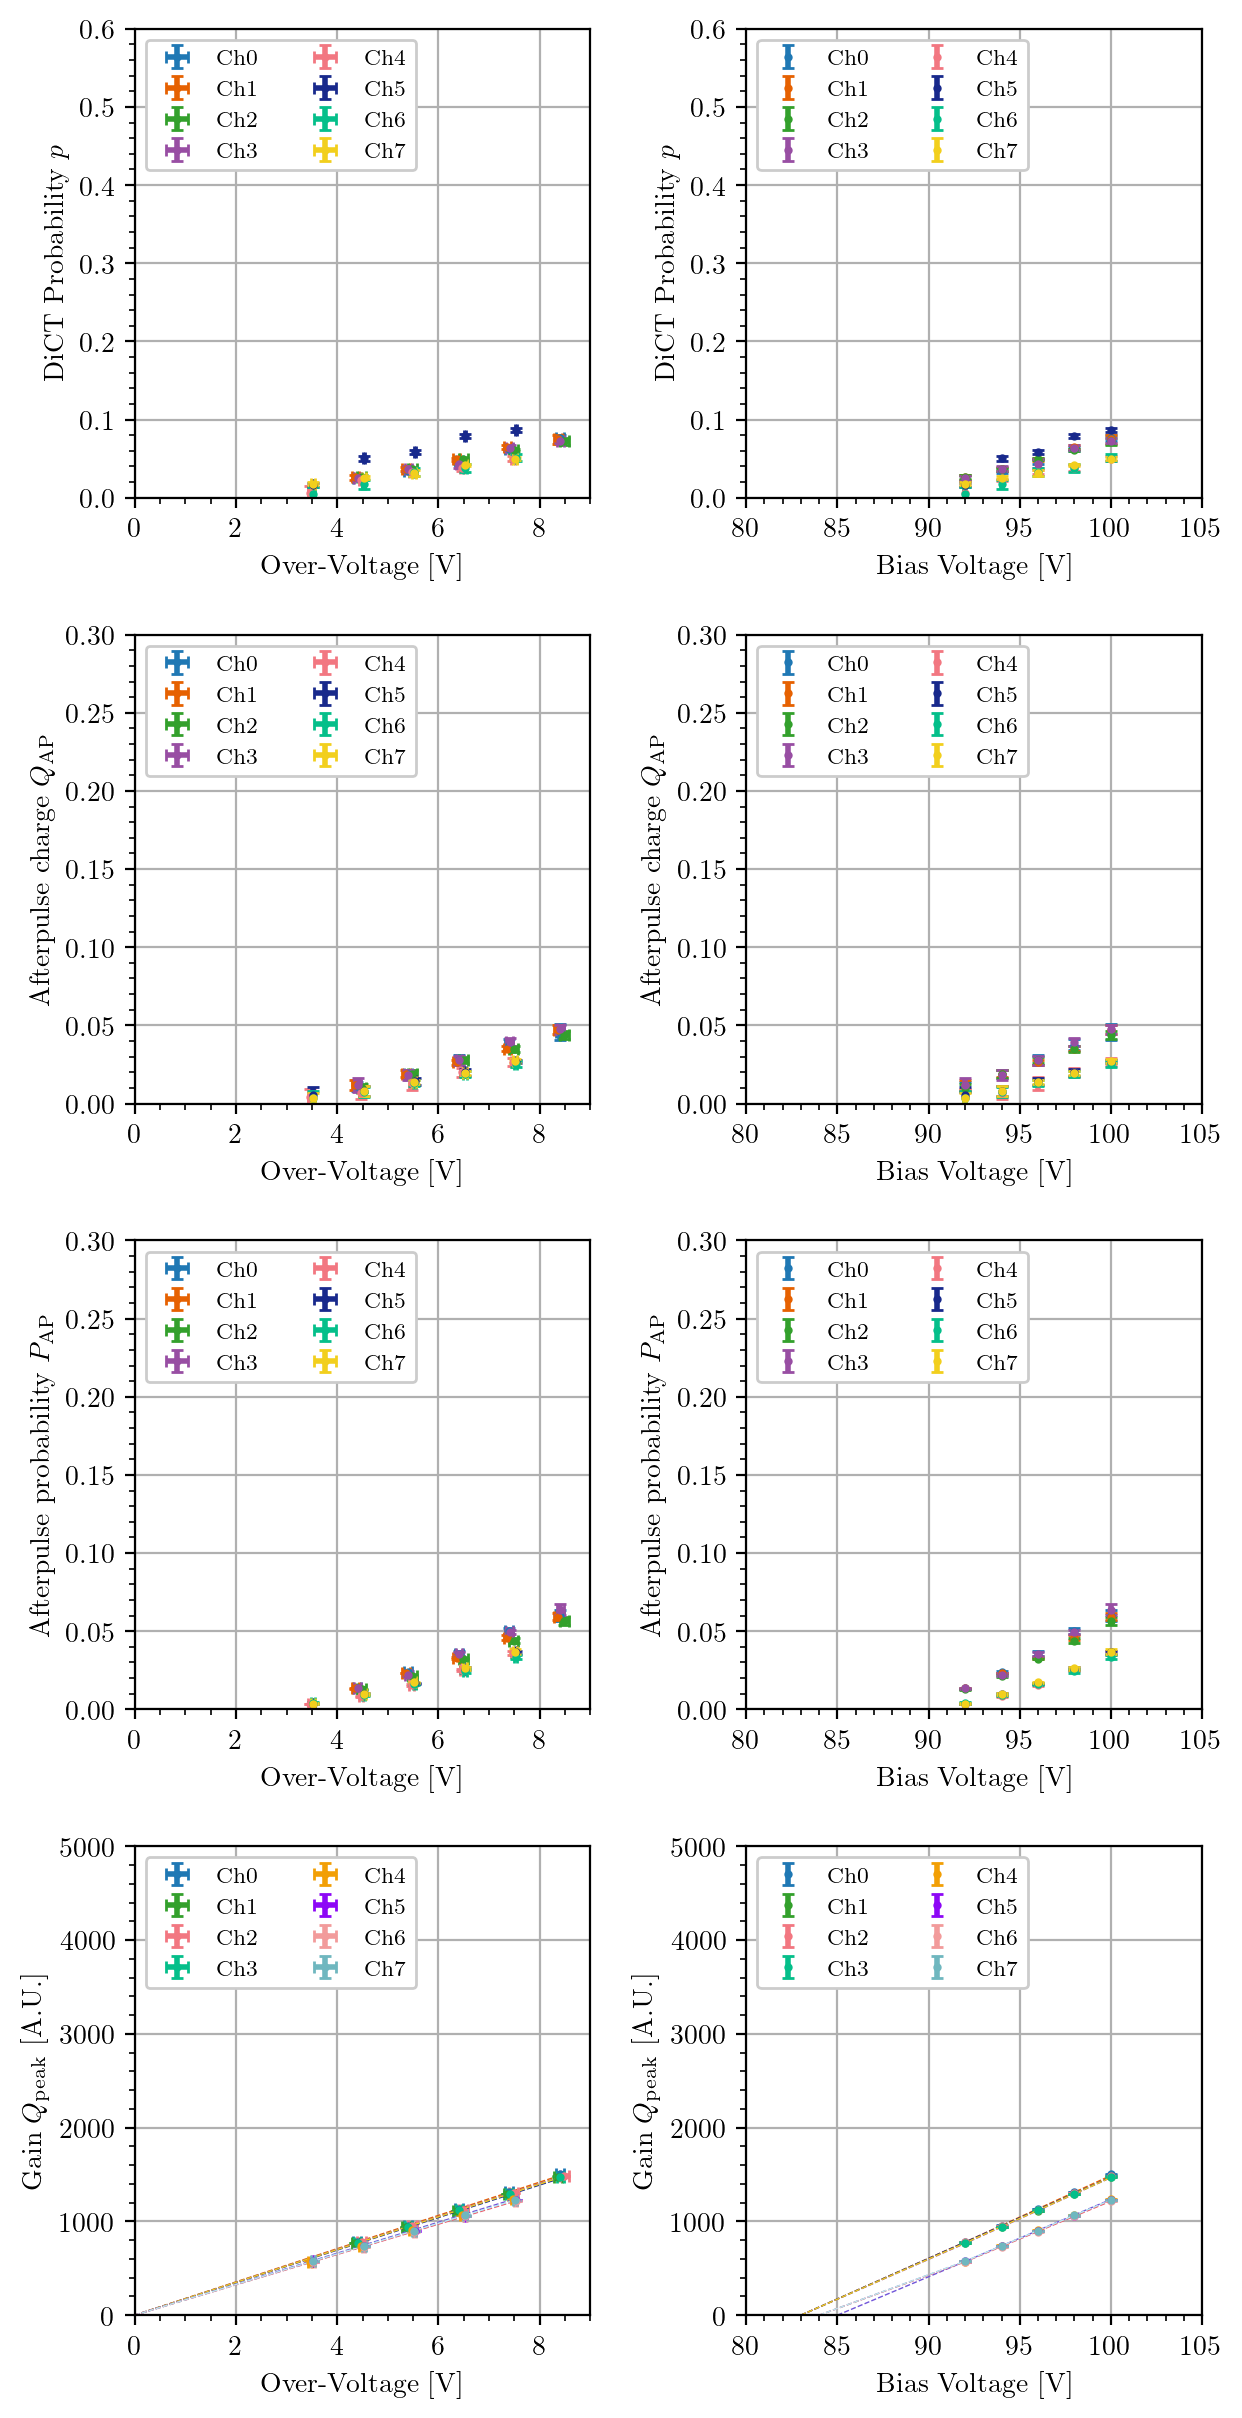

In [29]:
# Make summary plots
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

x_keys = ['ov','bias']
y_keys = ['dict','ap_charge', 'ap_prob', 'gain']
fig, axs = plt.subplots(len(y_keys),len(x_keys))
fig.set_size_inches(len(x_keys)*3, len(y_keys)*3)
fig.tight_layout(h_pad=3, w_pad=3)

for i,yk in enumerate(y_keys):
    for j,xk in enumerate(x_keys):
        for ch in channels:
            if xk=='ov':
                axs[i,j].errorbar(
                    results[yk][ch][xk],
                    results[yk][ch][yk],
                    xerr=results[yk][ch][f'{xk}_err'],
                    yerr=results[yk][ch][f'{yk}_err'],
                    label=f'Ch{ch}',
                    fmt='o',
                    markersize=2)
            elif xk=='bias':
                axs[i,j].errorbar(
                    results[yk][ch][xk],
                    results[yk][ch][yk],
                    yerr=results[yk][ch][f'{yk}_err'],
                    label=f'Ch{ch}',
                    fmt='o',
                    markersize=2)
            if yk=='gain':
                if xk=='ov':
                    axs[i,j].plot(
                        np.insert(results['gain'][ch]['ov'],0,0),
                        np.insert(results['gain'][ch]['ov']*vbd_fits[ch]['par'][0]*2,0,0),
                        '--',
                        linewidth=0.5)
                elif xk=='bias':
                    axs[i,j].plot(
                        np.insert(results['gain'][ch]['bias'],0,vbd_fits[ch]['vbd']),
                        np.insert((results['gain'][ch]['bias']-vbd_fits[ch]['vbd'])*vbd_fits[ch]['par'][0],0,0),
                        '--',
                        linewidth=0.5)
        axs[i,j].legend(ncol=2)
        if j==0:
            axs[i,j].set_xlabel(r'Over-Voltage [V]')
            axs[i,j].set_xlim(0, 9)
        else:
            axs[i,j].set_xlabel(r'Bias Voltage [V]')
            axs[i,j].set_xlim(80, 105)
        if i==0:
            axs[i,j].set_ylabel(r'DiCT Probability $p$')
            axs[i,j].set_ylim(0, 0.6)
        elif i==1:
            axs[i,j].set_ylabel(r'Afterpulse charge $Q_{\rm AP}$')
            axs[i,j].set_ylim(0, 0.3)
        elif i==2:
            axs[i,j].set_ylabel(r'Afterpulse probability $P_{\rm AP}$')
            axs[i,j].set_ylim(0, 0.3)
        elif i==3:
            axs[i,j].set_ylabel(r'Gain $Q_{\rm peak}$ [A.U.]')
            axs[i,j].set_ylim(0, 5e3)
        axs[i,j].grid()
        axs[i,j].minorticks_on()

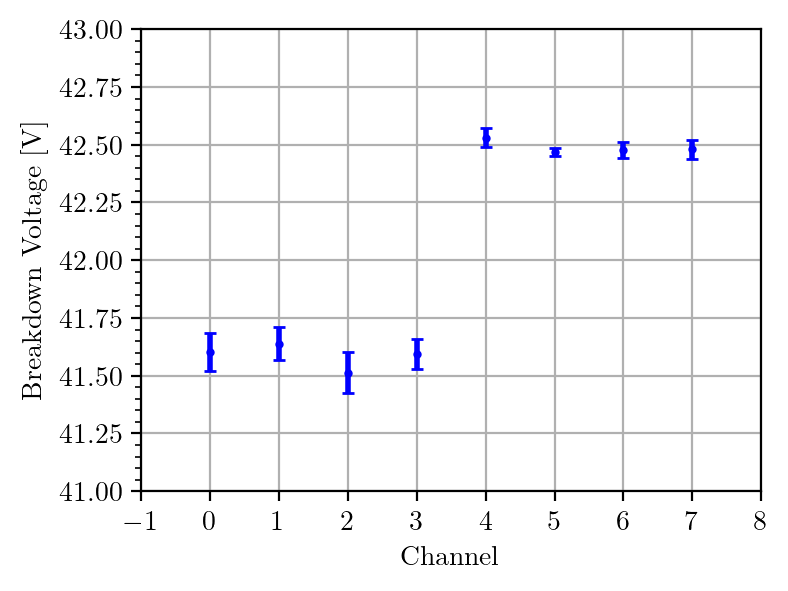

In [30]:
# Vbd-channel
fig, ax = plt.subplots()
channel_labels = []
for ch in channels:
    plt.errorbar(
        [ch], 
        [results['vbd'][ch]['vbd_sipm']],
        yerr=[results['vbd'][ch]['vbd_sipm_err']],
        fmt='bo', markersize=2)
    channel_labels.append(f'Ch{ch}')
plt.xlabel('Channel')
plt.ylabel('Breakdown Voltage [V]')
plt.xlim(-1, 8)
plt.ylim(41, 43)
plt.grid()
plt.minorticks_on()
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_tick_params(which='minor', bottom=False)
plt.show()

# Write to HDF5 file

In [31]:
h5filename = f'data/calibration_liq5_2023-12-13.h5'
columns = ['channel', 'A1min', 'A1max', 'DiCT', 'DiCT_err', 'Qavg', 'Qavg_err', 'Qpeak', 'Qpeak_err', 'Qap', 'Qap_err', 'bsl_rms', 'fano']
fano = {}
for ch in channels:
    fano[ch] = {}
    for volt in voltages:
        fano[ch][volt] = 1 + crosstalk[ch][volt]['dict'] + v2_smear[ch][volt]*gain_peak_fits[ch][volt]['Qpeak']/gain_avg_fits[ch][volt]['Qavg']*(1-crosstalk[ch][volt]['dict'])
for volt in voltages:
    store = pd.HDFStore(h5filename)
    store.put(f'{volt}V',pd.DataFrame(np.array([[
        ch,
        amp_hist[ch][volt]['boundaries'][1],
        amp_hist[ch][volt]['boundaries'][2],
        crosstalk[ch][volt]['dict'],
        crosstalk[ch][volt]['dict_err'],
        gain_avg_fits[ch][volt]['Qavg'],
        gain_avg_fits[ch][volt]['Qavg_err'],
        gain_peak_fits[ch][volt]['Qpeak'],
        gain_peak_fits[ch][volt]['Qpeak_err'],
        ap_charge[ch][volt]['Qap'],
        ap_charge[ch][volt]['Qap_err'],
        mybsl[ch][volt]['rms_threshold'],
        fano[ch][volt]
    ] for ch in channels]), columns=columns).astype({'channel':'int'}))
    store.close()

In [32]:
store = pd.HDFStore(h5filename)
store.keys()

['/100V', '/92V', '/94V', '/96V', '/98V']

In [33]:
store.close()

## Calculate rENF versus bias/over-voltage

Following https://ieeexplore.ieee.org/document/5402300 closely, the reduced excess noise factor (rENF) here is defined as
$$\mathrm{rENF}(V_{\rm bias})=\frac{F}{\mu},$$
where $F$ is the Fano factor, and $\mu$ is the parameter obtained from the Vinogradov fits.
Since the laser intensity did not change when taking data at different voltages, $\mu$ is the relative PDE. We choose $V_{\rm bias}=92V$ as the reference point.


In [34]:
results['renf'] = {}
for ch in channels:
    results['renf'][ch] = {}
    results['renf'][ch]['bias'] = np.array(voltages)
    results['renf'][ch]['ov'] = results['renf'][ch]['bias']/nsipms-results['vbd'][ch]['vbd_sipm']
    results['renf'][ch]['ov_err'] = np.ones(results['renf'][ch]['ov'].shape[0])*results['vbd'][ch]['vbd_sipm_err']
    results['renf'][ch]['renf'] = np.array([fano[ch][volt]/(crosstalk[ch][volt]['par'][0]/crosstalk[ch][voltages[0]]['par'][0]) for volt in voltages])
    # results['renf'][ch]['renf_err'] = results['renf'][ch]['renf']*np.array([ ( crosstalk[ch][volt]['cov'][0,0]/(crosstalk[ch][volt]['par'][0])**2 + crosstalk[ch][volt]['cov'][1,1]/(1+crosstalk[ch][volt]['par'][1])**2 )**0.5 for volt in voltages])


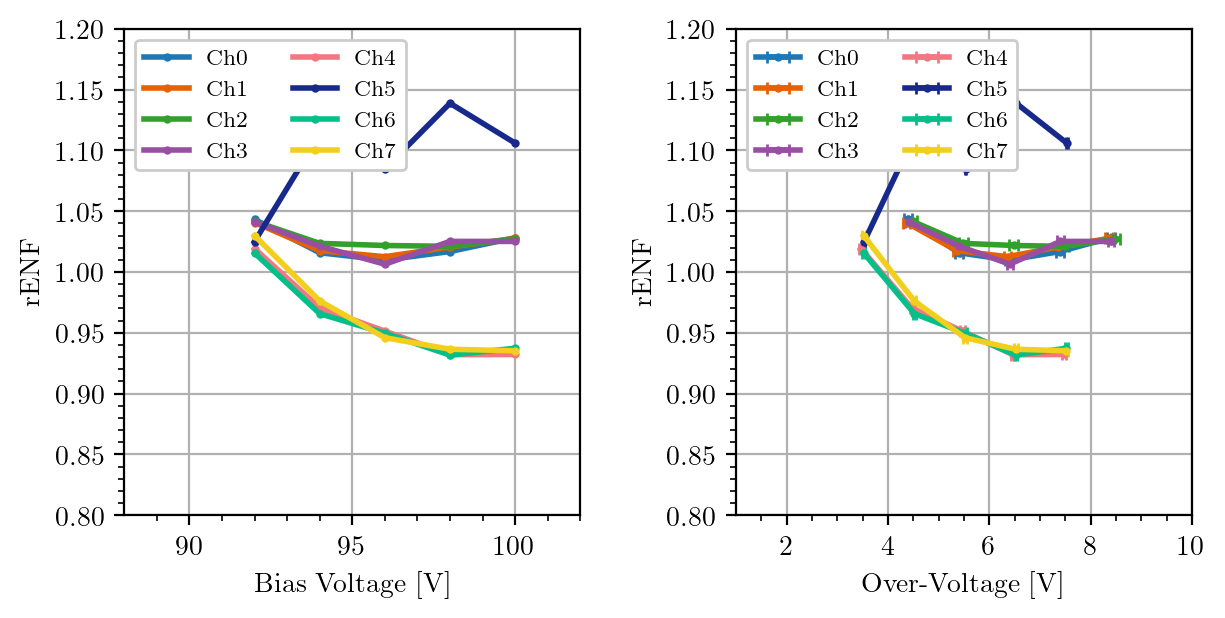

In [36]:
# Relative PDE: the mu parameter from the DiCT fits
fig, axs = plt.subplots(1,2)
fig.set_size_inches(6, 3)
fig.tight_layout(h_pad=3, w_pad=3)
for ch in channels:
    axs[0].errorbar(
        results['renf'][ch]['bias'],
        results['renf'][ch]['renf'],
        # yerr=results['renf'][ch]['renf_err'],
        label=f'Ch{ch}',
        fmt='C{}o-'.format(ch),
        markersize=2)
    axs[1].errorbar(
        results['renf'][ch]['ov'],
        results['renf'][ch]['renf'],
        xerr=results['renf'][ch]['ov_err'],
        # yerr=results['renf'][ch]['renf_err'],
        label=f'Ch{ch}',
        fmt='C{}o-'.format(ch),
        markersize=2)
for i in [0,1]:
    if i==0:
        axs[i].set_xlabel('Bias Voltage [V]')
        axs[i].set_xlim(88, 102)
    else:
        axs[i].set_xlabel('Over-Voltage [V]')
        axs[i].set_xlim(1, 10)

    axs[i].set_ylabel('rENF')
    axs[i].legend(ncol=2)
    axs[i].grid()
    axs[i].minorticks_on()
    axs[i].set_ylim(0.8,1.20)
    